# CML to FAIRFluids Conversion - Composition-Based Approach

This notebook demonstrates how to convert CML (Chemical Markup Language) files to FAIRFluids format using the `FAIRFluidsCMLParser` class with the new **composition-based approach**.

## Key Features

- **Composition-based fluid creation**: $E_a$ch unique composition gets its own fluid block
- **Automatic compound ID generation** with consistent naming
- **Support for multiple property types** (viscosity, conductivity, density)
- **Intelligent composition grouping** based on mole fraction combinations
- **No filtering needed**: Only compounds present in each composition are included

## Overview

The parser automatically:
1. Extracts compounds from CML data or uses provided compound definitions
2. Generates consistent compound IDs using cleaned common names
3. **Groups measurements by unique compositions** (mole fraction combinations)
4. **Creates separate fluid blocks for each unique composition**
5. **Only includes compounds with non-zero mole fractions in each fluid**
6. Creates parameter definitions specific to each composition
7. Assigns measurements to the appropriate fluid based on composition

## Important Notes

- **Composition-Based Approach**: $E_a$ch unique composition becomes a separate fluid block
- **No Zero Mole Fractions**: Compounds with zero mole fractions are automatically excluded from each fluid
- **Consistent IDs**: Compound and parameter IDs use cleaned names for consistency
- **Clean Data Structure**: No post-processing filtering needed - data is structured correctly from the start

In [29]:
# Import the FAIRFluids models
import sys
sys.path.append('/home/sga/Code/FAIRFluids')
from fairfluids import FAIRFluidsCMLParser
from fairfluids.core.lib import FAIRFluidsDocument, Version, Citation
from fairfluids.core.functionalities import FAIRFluidsCMLParser
from fairfluids import FAIRFluidsDocument, FluidIO, calculate_ratio_of_solvent
from fairfluids.core.visualization import extract_fairfluids_data, plot_dataframe

# Test the extended class
doc = FAIRFluidsDocument(
    version=Version(
        versionMajor=1,
        versionMinor=0
    )
)

# Add same data as example
doc.citation = Citation(Type="journal")
doc.citation.add_to_author(given_name="Gudrun", family_name="Gygli")

# Define the compounds as variables (dictionaries) for use in a compounds list
# Note: compoundID will be automatically generated using the new consistent naming convention
compound_water = {
    "pubChemID": 962,
    "commonName": "Water",
    "name_IUPAC": "oxidane",
    "standard_InChI": "InChI=1S/H2O/h1H2",
    "standard_InChI_key": "XLYOFNOQVPJJNP-UHFFFAOYSA-N"
}

compound_cholinechloride = {
    "pubChemID": 6209,
    "commonName": "Choline chloride",  # Updated to use proper spacing
    "name_IUPAC": "Choline chloride",
    "standard_InChI": "InChI=1S/C5H11ClNO2/c1"
}

compound_glycerol = {
    "pubChemID": 753,
    "commonName": "Glycerol",
    "name_IUPAC": "glycerol",
    "standard_InChI": "InChI=1S/C3H8O3/c1-2-3-4/h2-3H,1H3",
    "standard_InChI_key": "XLYOFNOQVPJJNP-UHFFFAOYSA-N"
}

compound_urea = {
    "pubChemID": 1176,
    "commonName": "Urea",
    "name_IUPAC": "urea",
    "standard_InChI": "InChI=1S/C2H4N2O/c1-2-4-3/h1H3,(H,2,4)"
}

compounds = [
        compound_cholinechloride,
        compound_glycerol,
        compound_water
    ]
    


# Path to the test CML file
cml_path = "/home/sga/Code/FAIRFluids/fairfluids/data/cml_xml/xu/CML_exp_sim.xml"
#cml_path = "/home/sga/Code/FAIRFluids/fairfluids/data/cml_xml/xu/CML_exp_sim.xml"




# Parse the CML file
parser = FAIRFluidsCMLParser(cml_path, compounds=compounds)
doc = parser.parse()

doc   = calculate_ratio_of_solvent(
    doc=doc,
    parameter_id_1="parameter_mole_fraction_glycerol",
    parameter_id_2="parameter_mole_fraction_cholinechloride",
    name="urea_cholinechloride",
    compound_id_1="compound_glycerol",
    compound_id_2="compound_cholinechloride",
    precision=1  # Round to 2 decimal places - ensures 2.0 instead of 2.0075...
)

# Save the model to a JSON file
with open('/home/sga/Code/FAIRFluids/Workflows/paper_outputs/Xu_Glycerol_Water.json', 'w') as f:
    f.write(doc.model_dump_json(indent=4))
    
print(f"\n📁 Output saved to: /home/sga/Code/FAIRFluids/Workflows/outputs/Xu_Glycerol_Water.json")

Fetching compound data from PubChem for CID 6209...
Successfully fetched and merged data for CID 6209
Fetching compound data from PubChem for CID 753...
Successfully fetched and merged data for CID 753
Fetching compound data from PubChem for CID 962...
Successfully fetched and merged data for CID 962
Found 52 unique compositions
Composition (0.5, 0.5, 0.0): compounds ['compound_cholinechloride', 'compound_glycerol']
Composition (0.333, 0.667, 0.0): compounds ['compound_cholinechloride', 'compound_glycerol']
Composition (0.25, 0.75, 0.0): compounds ['compound_cholinechloride', 'compound_glycerol']
Composition (0.05, 0.95, 0.0): compounds ['compound_cholinechloride', 'compound_glycerol']
Composition (0.1, 0.9, 0.0): compounds ['compound_cholinechloride', 'compound_glycerol']
Composition (0.15, 0.85, 0.0): compounds ['compound_cholinechloride', 'compound_glycerol']
Composition (0.2, 0.8, 0.0): compounds ['compound_cholinechloride', 'compound_glycerol']
Composition (0.3, 0.7, 0.0): compoun

In [30]:
# Import der wiederverwendbaren Plot-Speicherfunktion
from fairfluids.core.plot_utils import save_plot_as_svg

# Die Funktion save_plot_as_svg() kann jetzt in allen Zellen verwendet werden
# Sie speichert automatisch Plots als SVG-Dateien im Verzeichnis 'image_output'
# und verwendet den Plot-Titel als Dateinamen (mit eindeutigem Zähler)


In [31]:
df_data_glyceline = extract_fairfluids_data(doc)

# Compute mole_fraction_water column for use in filtering
df_data_glyceline = df_data_glyceline.copy()
df_data_glyceline["mole_fraction_water"] = df_data_glyceline["mole_fractions"].apply(
    lambda mf: mf[-1] if isinstance(mf, (list, tuple)) and len(mf) > 0 else float('nan')
)

# Ensure mole_fraction_water is 1.0 when [Water] is the only component
def get_water_mole_fraction(row):
    """Get the mole fraction of water from fluid_compounds and mole_fractions."""
    if not isinstance(row["fluid_compounds"], list) or not isinstance(row["mole_fractions"], (list, tuple)):
        return 0.0
    
    # Find the position of water in fluid_compounds
    water_position = -1
    for i, compound in enumerate(row["fluid_compounds"]):
        if isinstance(compound, str) and compound.lower() in ['water', 'h2o']:
            water_position = i
            break
    
    # If water is found and mole_fractions has enough elements, return the mole fraction
    if water_position >= 0 and len(row["mole_fractions"]) > water_position:
        return row["mole_fractions"][water_position]
    else:
        return 0.0

df_data_glyceline["mole_fraction_water"] = df_data_glyceline.apply(get_water_mole_fraction, axis=1)

# Apply 0 to mole_fraction_water if only cholinechloride and glycerol is present in fluid_compounds
df_data_glyceline.loc[
    (df_data_glyceline["fluid_compounds"].apply(
        lambda comps: isinstance(comps, list)
        and len(comps) == 2
        and set(comps) == set(["Choline Chloride", "Glycerol"])
    )),
    "mole_fraction_water"
] = 0.0

# Additional dataframe for just [Choline Chloride, Glycerol]
df_reline_just_cc_gly = df_data_glyceline[
    df_data_glyceline["fluid_compounds"].apply(
        lambda comps: isinstance(comps, list)
        and len(comps) == 2
        and set(comps) == set(["Choline Chloride", "Glycerol"])
    )
]

# Filter for ratio == 2 OR (molefractions has water == 1)
df_data_glyceline_ratio_or_pure_water = df_data_glyceline[
    (df_data_glyceline["Solvent: Amount ratio of component to other component of binary solvent"] == 2)
    | (df_data_glyceline["mole_fraction_water"] == 1.0)
    | (df_data_glyceline["mole_fraction_water"] == 0.0)  # include the newly set 0.0 rows
]

# Sort by the water mole fraction, descending
df_data_glyceline_ratio_or_pure_water = df_data_glyceline_ratio_or_pure_water.sort_values(
    by="mole_fraction_water", ascending=False
)
df_data_glyceline_ratio_or_pure_water
#df_reline_just_cc_gly
# Save the dataframe as Excel to home directory
import os
excel_output_path = os.path.expanduser("~/df_data_glyceline_ratio_or_pure_water.xlsx")
df_data_glyceline_ratio_or_pure_water.to_excel(excel_output_path, index=False)
print(f"Saved dataframe to {excel_output_path}")




Saved dataframe to /home/sga/df_data_glyceline_ratio_or_pure_water.xlsx


✓ Plot gespeichert: image_output/Plot_of_ln_vs_RT_Grouped_by_DOI_14.svg (120,500 Bytes)


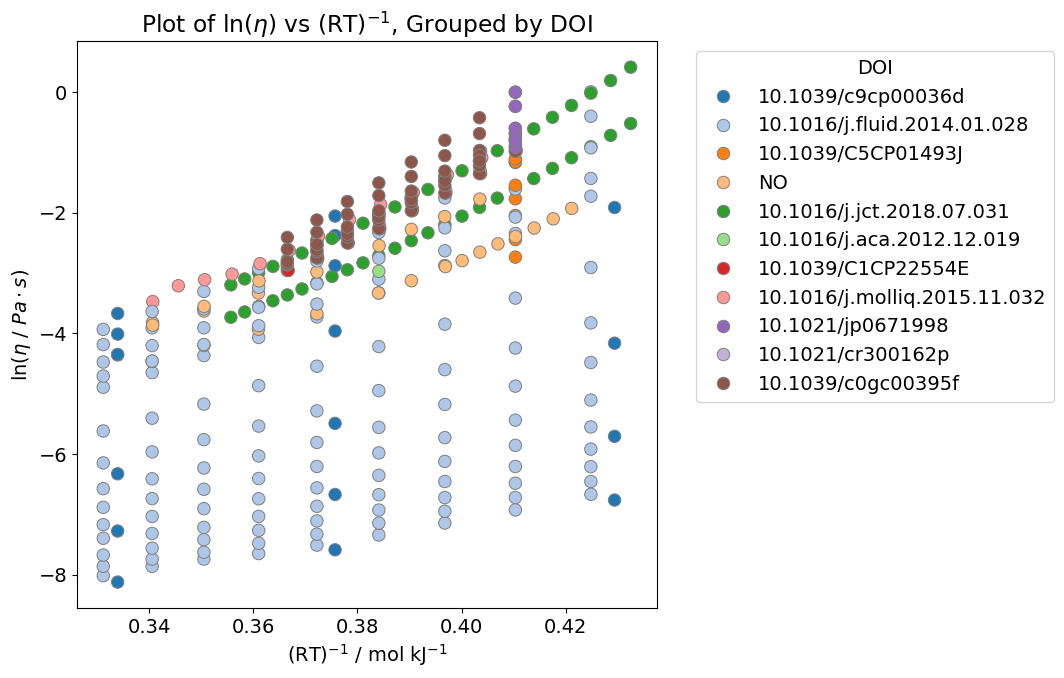

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make sure required columns exist
required_cols = ["viscosity_value", "temperature", "source_doi", "mole_fraction_water"]
for col in required_cols:
    if col not in df_data_glyceline_ratio_or_pure_water.columns:
        raise ValueError(f"Column '{col}' not found in dataframe.")

# Filter out rows with missing data
plot_df = df_data_glyceline_ratio_or_pure_water[df_data_glyceline_ratio_or_pure_water["viscosity_value"].notnull() & df_data_glyceline_ratio_or_pure_water["temperature"].notnull() & df_data_glyceline_ratio_or_pure_water["source_doi"].notnull()]

# Calculate ln(viscosity) and 1/RT (Kelvin)
# Use R = 8.314 J/(mol*K), but since it's unitless vs. 1/K, you can leave as 1/T or explicitly use 1/(R*T)
R = 8.314 # J/(mol*K)
plot_df = plot_df.copy()
plot_df["inv_RT"] = 1000 / (R * plot_df["temperature"].astype(float))
plot_df["ln_viscosity"] = np.log(plot_df["viscosity_value"].astype(float))

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=plot_df,
    x="inv_RT",
    y="ln_viscosity",
    hue="source_doi",
    palette='tab20',
    s=80,
    edgecolor='gray'
)
plt.title(r'Plot of ln($\eta$) vs (RT)$^{-1}$, Grouped by DOI')
plt.xlabel(r'(RT)$^{-1}$ / mol kJ$^{-1}$')
plt.ylabel(r'ln($\eta$ / $Pa \cdot s$)')
plt.legend(title="DOI", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
save_plot_as_svg()
plt.show()


/tmp/ipykernel_13941/2964956621.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues', N)


✓ Plot gespeichert: image_output/Plot_of_ln_vs_1RT_Grouped_by_water_mole_fraction_15.svg (115,375 Bytes)


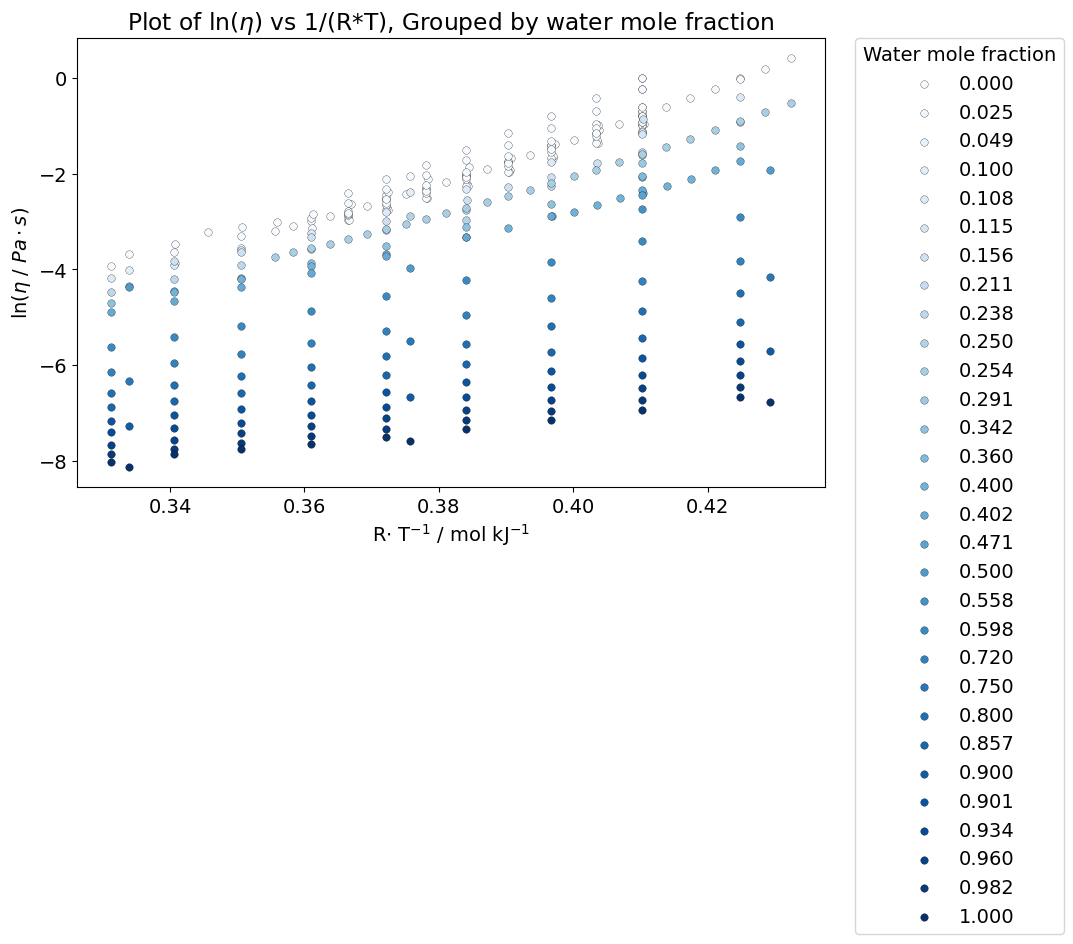

All linear fit activation energies by water mole fraction:


,water_mole_fraction,activation_energy
0,0.000,44.435182
1,0.100,39.132853
2,0.108,40.366403
3,0.156,38.285661
4,0.238,37.590289
5,0.250,29.986001
6,0.254,41.597359
7,0.342,34.740694
8,0.400,31.063405
9,0.402,33.526415


In [33]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from scipy.stats import linregress

# Make sure required columns exist
required_cols = ["viscosity_value", "temperature", "source_doi", "mole_fraction_water"]
for col in required_cols:
    if col not in df_data_glyceline_ratio_or_pure_water.columns:
        raise ValueError(f"Column '{col}' not found in dataframe.")

# Fill missing/None values in mole_fraction_water with 0
df_data_glyceline_ratio_or_pure_water = df_data_glyceline_ratio_or_pure_water.copy()
df_data_glyceline_ratio_or_pure_water["mole_fraction_water"] = (
    df_data_glyceline_ratio_or_pure_water["mole_fraction_water"]
    .fillna(0)
    .apply(lambda x: 0 if x is None else x)
)

# Filter out rows with missing data
plot_df = df_data_glyceline_ratio_or_pure_water[
    df_data_glyceline_ratio_or_pure_water["viscosity_value"].notnull() &
    df_data_glyceline_ratio_or_pure_water["temperature"].notnull() &
    df_data_glyceline_ratio_or_pure_water["source_doi"].notnull()
].copy()

# Calculate ln(viscosity) and 1/(R*T)
R = 8.314  # J/(mol*K)
plot_df["inv_RT"] = 1000 / (R * plot_df["temperature"].astype(float))
plot_df["ln_viscosity"] = np.log(plot_df["viscosity_value"].astype(float))

# Use mole_fraction_water to color the water amount
plot_df["water_mole_fraction"] = plot_df["mole_fraction_water"].astype(float)

# We'll use unique discrete values for water mole fraction as hue
plot_df["water_mole_fraction_rounded"] = plot_df["water_mole_fraction"].round(3)
discrete_mole_fractions = np.sort(plot_df["water_mole_fraction_rounded"].unique())

# Set up colormap: Blues colormap, N bins = number of unique mole fractions
N = len(discrete_mole_fractions)
cmap = cm.get_cmap('Blues', N)
color_dict = {mf: cmap(i) for i, mf in enumerate(discrete_mole_fractions)}

plt.figure(figsize=(11,8))
ax = plt.gca()

# Scatter points for each discrete fraction, so legend can be discrete
for i, mf in enumerate(discrete_mole_fractions):
    subset = plot_df[plot_df["water_mole_fraction_rounded"] == mf]
    ax.scatter(
        subset["inv_RT"], 
        subset["ln_viscosity"], 
        color=color_dict[mf],
        s=30, 
        edgecolor='black',
        linewidth=0.2,
        label=f"{mf:.3f}"
    )

# Linear fit and store slopes per discrete water content
slope_results = []
for mf in discrete_mole_fractions:
    group = plot_df[plot_df["water_mole_fraction_rounded"] == mf]
    if len(group) >= 2:
        x = group["inv_RT"].values
        y = group["ln_viscosity"].values
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        xfit = np.linspace(x.min(), x.max(), 50)
        yfit = intercept + slope * xfit
        # Optional: plot the fits in same color, commented out for clarity
        # ax.plot(xfit, yfit, linestyle='--', linewidth=2, color=color_dict[mf])
        mf_tuple = tuple(group["mole_fractions"].iloc[0]) if "mole_fractions" in group.columns and isinstance(group["mole_fractions"].iloc[0], (list, tuple)) else group["mole_fractions"].iloc[0] if "mole_fractions" in group.columns else None
        slope_results.append({
            "mole_fractions": mf_tuple,
            "water_mole_fraction": float(mf),
            "slope": slope
        })

# Make discrete legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
lgd = ax.legend(by_label.values(), by_label.keys(), title="Water mole fraction", bbox_to_anchor=(1.04, 1), loc='upper left', borderaxespad=0.)

plt.title(r'Plot of ln($\eta$) vs 1/(R*T), Grouped by water mole fraction')
plt.xlabel(r'R$ \cdot$ T$^{-1}$ / mol kJ$^{-1}$')
plt.ylabel(r'ln($\eta$ / $Pa \cdot s$)')
plt.tight_layout()
save_plot_as_svg()
plt.show()

import pandas as pd
activation_energy_df = pd.DataFrame(slope_results)
activation_energy_df = activation_energy_df.rename(columns={'slope': 'activation_energy'})
print("All linear fit activation energies by water mole fraction:")
display(activation_energy_df[["water_mole_fraction", "activation_energy"]])


✓ Plot gespeichert: image_output/Plot_of_lnviscosity_vs_1RT_colors_by_DOI_marker_by_16.svg (114,258 Bytes)


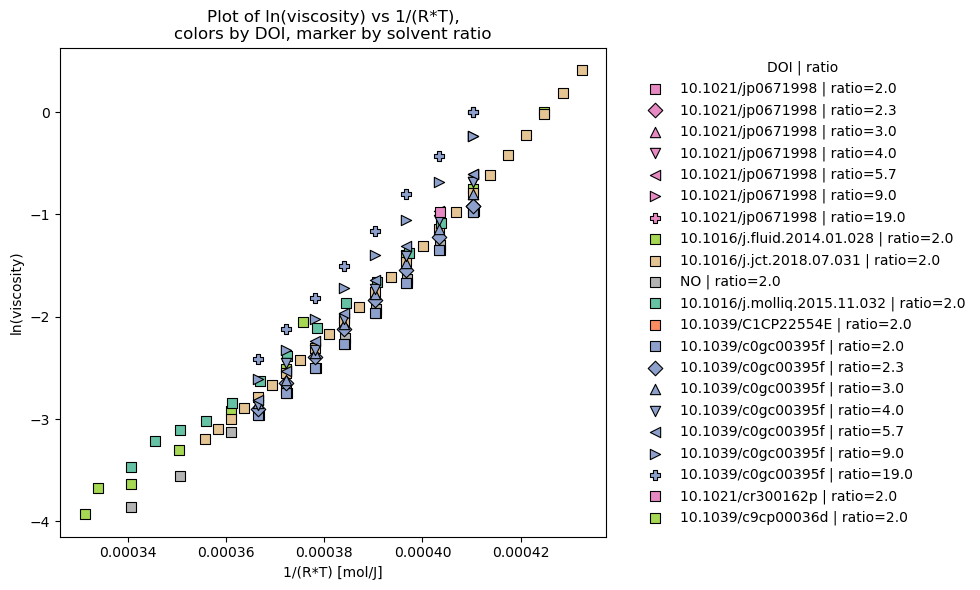

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Remove the gray background globally
plt.style.use('default')

fig, ax = plt.subplots(figsize=(10, 6))

# Calculate inv_RT and ln_viscosity if not already present, use correct dataframe columns
if "inv_RT" not in df_reline_just_cc_gly.columns or "ln_viscosity" not in df_reline_just_cc_gly.columns:
    R = 8.314462618  # J/(mol*K)
    df_reline_just_cc_gly = df_reline_just_cc_gly.copy()
    df_reline_just_cc_gly["inv_RT"] = 1 / (R * df_reline_just_cc_gly["temperature"])
    # Defensive: Make sure viscosity_value column is numeric and positive
    viscosity_numeric = pd.to_numeric(df_reline_just_cc_gly["viscosity_value"], errors='coerce')
    # Replace/mark as NaN any infeasible values (<=0 or failed conversion)
    bad_mask = (viscosity_numeric.isna()) | (viscosity_numeric <= 0)
    if bad_mask.any():
        print(f"Warning: {bad_mask.sum()} rows in viscosity_value are NaN, <=0, or invalid. These will be skipped for ln(viscosity).")
    ln_viscosity = np.full_like(viscosity_numeric, np.nan, dtype=np.float64)
    ln_viscosity[~bad_mask] = np.log(viscosity_numeric[~bad_mask])
    df_reline_just_cc_gly["ln_viscosity"] = ln_viscosity

# Use different marker shapes for different "Solvent: Amount ratio of component to other component of binary solvent"
if "glycerol_cholinechloride" in df_reline_just_cc_gly.columns:
    ratio_col = "glycerol_cholinechloride"
elif "Solvent: Amount ratio of component to other component of binary solvent" in df_reline_just_cc_gly.columns:
    ratio_col = "Solvent: Amount ratio of component to other component of binary solvent"
else:
    ratio_col = None

if ratio_col is not None:
    unique_ratios = df_reline_just_cc_gly[ratio_col].dropna().unique()
    ratios_sorted = np.sort(unique_ratios)
    # Common matplotlib marker styles, enough for up to 8 unique ratios
    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'P', '*', 'X', 'h', 'H']
    marker_styles = {ratio: markers[i % len(markers)] for i, ratio in enumerate(ratios_sorted)}
else:
    marker_styles = None

# Get unique DOIs and assign colors
dois = df_reline_just_cc_gly["source_doi"].unique()
colors = plt.cm.Set2.colors
color_map = {doi: colors[i % len(colors)] for i, doi in enumerate(dois)}

legend_handles = []
for doi in dois:
    doi_subset = df_reline_just_cc_gly[
        (df_reline_just_cc_gly["source_doi"] == doi)
        & (~df_reline_just_cc_gly["inv_RT"].isna())
        & (~df_reline_just_cc_gly["ln_viscosity"].isna())
    ]
    if marker_styles is not None and ratio_col is not None:
        for ratio in sorted(marker_styles.keys()):
            subset = doi_subset[doi_subset[ratio_col] == ratio]
            if subset.empty:
                continue
            handle = ax.scatter(
                subset["inv_RT"],
                subset["ln_viscosity"],
                label=f"{doi}\nratio={ratio}",
                marker=marker_styles[ratio],
                color=color_map[doi],
                s=55,
                edgecolor='black',
                linewidth=0.8,
            )
            # Collect one handle per ratio:doi for custom legend
            legend_handles.append((f"{doi} | ratio={ratio}", handle))
    else:
        subset = doi_subset
        handle = ax.scatter(
            subset["inv_RT"],
            subset["ln_viscosity"],
            label=doi,
            color=color_map[doi],
            s=20,
            edgecolor='black',
            linewidth=0.1
        )
        legend_handles.append((doi, handle))

ax.set_xlabel('1/(R*T) [mol/J]')
ax.set_ylabel('ln(viscosity)')

# Remove default axes and legend background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Custom legend: show one per DOI+ratio combination if marker_styles exist
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

if marker_styles is not None:
    unique_labels = {}
    for lbl, h in legend_handles:
        if lbl not in unique_labels:
            unique_labels[lbl] = h
    leg = ax.legend(unique_labels.values(), unique_labels.keys(), title='DOI | ratio', bbox_to_anchor=(1.04, 1), loc='upper left', frameon=False)
else:
    leg = ax.legend(title='DOI', bbox_to_anchor=(1.04, 1), loc='upper left', frameon=False)

ax.set_title('Plot of ln(viscosity) vs 1/(R*T),\ncolors by DOI, marker by solvent ratio')
plt.tight_layout()
save_plot_as_svg()
plt.show()


In [35]:
# Calculate activation energies for each DOI and each ratio exactly as in cell 72-96 (see file_context_0)
from scipy.stats import linregress

activation_energy_results = []
for mf in [0]:  # This dataset is for pure reline (no water), so mole fraction is always 0
    group = df_reline_just_cc_gly  # All of this DF has water_mole_fraction = 0
    # For each unique source_doi in this water content, do a fit for that subset
    for doi in group["source_doi"].unique():
        doi_group = group[group["source_doi"] == doi]
        # Find proper ratio column
        if "glycerol_cholinechloride" in doi_group.columns:
            ratio_col = "glycerol_cholinechloride"
        elif "Solvent: Amount ratio of component to other component of binary solvent" in doi_group.columns:
            ratio_col = "Solvent: Amount ratio of component to other component of binary solvent"
        else:
            ratio_col = None

        # Work as in (72-96): group by ratio (if exists) or just DOI
        if ratio_col is not None:
            for ratio in sorted(doi_group[ratio_col].dropna().unique()):
                if ratio == 2:
                    continue  # Skip those with molar_ratio == 2
                sub2 = doi_group[
                    (doi_group[ratio_col] == ratio)
                    & (~doi_group["inv_RT"].isna())
                    & (~doi_group["ln_viscosity"].isna())
                ]
                if len(sub2) >= 2:
                    x = sub2["inv_RT"].values
                    y = sub2["ln_viscosity"].values
                    slope, intercept, r_value, p_value, std_err = linregress(x, y)
                    activation_energy_results.append({
                        "water_mole_fraction": float(mf),
                        "activation_energy": abs(slope),
                        "source_doi": doi,
                        "ordinate": intercept,
                        "statistic": r_value,
                        "molar_ratio": ratio,
                    })
        else:
            sub2 = doi_group[
                (~doi_group["inv_RT"].isna())
                & (~doi_group["ln_viscosity"].isna())
            ]
            if len(sub2) >= 2:
                x = sub2["inv_RT"].values
                y = sub2["ln_viscosity"].values
                slope, intercept, r_value, p_value, std_err = linregress(x, y)
                activation_energy_results.append({
                    "water_mole_fraction": float(mf),
                    "activation_energy": abs(slope),
                    "source_doi": doi,
                    "ordinate": intercept,
                    "statistic": r_value,
                    "molar_ratio": None,
                })

activation_energies_pure = pd.DataFrame(activation_energy_results)
display(activation_energies_pure)


,water_mole_fraction,activation_energy,source_doi,ordinate,statistic,molar_ratio
0,0.0,45502.133942,10.1039/c0gc00395f,-19.587819,0.999903,2.3
1,0.0,47045.892294,10.1039/c0gc00395f,-20.124261,0.999625,3.0
2,0.0,48304.321208,10.1039/c0gc00395f,-20.543573,0.997493,4.0
3,0.0,50296.423067,10.1039/c0gc00395f,-21.256798,0.999803,5.7
4,0.0,53401.786797,10.1039/c0gc00395f,-22.208433,0.999157,9.0
5,0.0,54772.293625,10.1039/c0gc00395f,-22.513597,0.999573,19.0


<>:64: SyntaxWarning: invalid escape sequence '\c'
<>:64: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_13941/580043810.py:64: SyntaxWarning: invalid escape sequence '\c'
  ax2.set_xlabel('$R \cdot T^{-1}$ / mol J$^{-1}$', fontsize=14)


✓ Plot gespeichert: image_output/Arrhenius_plot_of_Glyceline_Component_ratio_12_17.svg (98,442 Bytes)


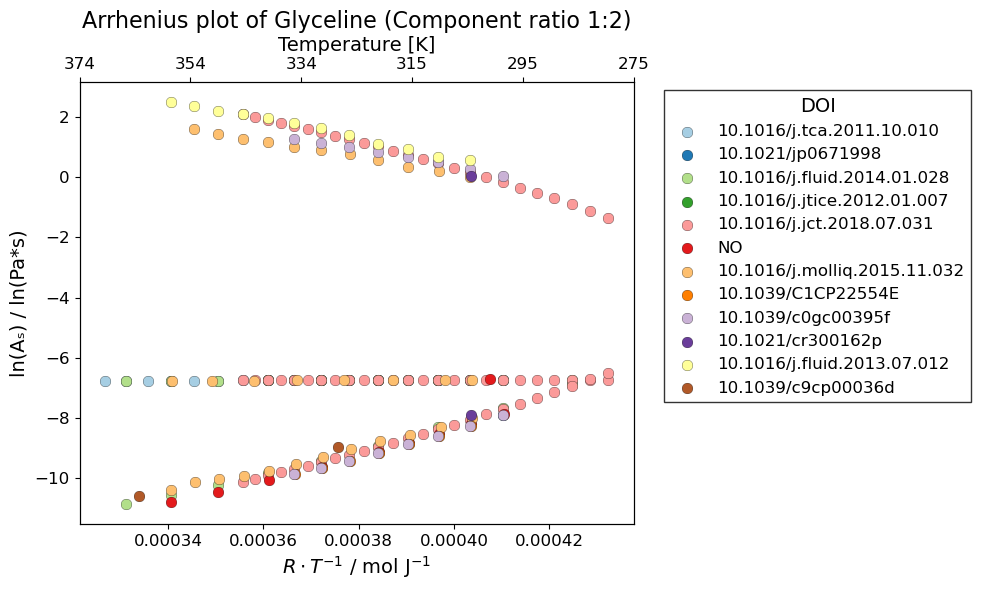

In [36]:
# Plot ln(viscosity/1000) vs 1/(R*T) but only for "Solvent: Amount ratio of component to other component of binary solvent" == 2
# with no grey background (no 'ggplot' style)

# Remove previous style settings to avoid grey background
plt.style.use('default')

ratio_of_interest = 2

if "glycerol_cholinechloride" in df_reline_just_cc_gly.columns:
    ratio_col_plot2 = "glycerol_cholinechloride"
elif "Solvent: Amount ratio of component to other component of binary solvent" in df_reline_just_cc_gly.columns:
    ratio_col_plot2 = "Solvent: Amount ratio of component to other component of binary solvent"
else:
    ratio_col_plot2 = None

if ratio_col_plot2 is not None:
    filtered_df = df_reline_just_cc_gly[df_reline_just_cc_gly[ratio_col_plot2] == ratio_of_interest].copy()
else:
    filtered_df = df_reline_just_cc_gly.copy()  # fallback: plot all

# Check if 'viscosity' column exists, if not use 'property_value'
if 'viscosity' in filtered_df.columns:
    viscosity_col = 'viscosity'
elif 'property_value' in filtered_df.columns:
    viscosity_col = 'property_value'
else:
    print("Error: Neither 'viscosity' nor 'property_value' column found in the dataframe")
    print("Available columns:", filtered_df.columns.tolist())
    viscosity_col = None

if viscosity_col is not None:
    # Calculate ln(viscosity/1000) for the filtered data
    filtered_df["ln_viscosity_scaled"] = np.log(filtered_df[viscosity_col] / 1000)

    fig2, ax2 = plt.subplots(figsize=(10, 6))

    # Set background to white explicitly
    fig2.patch.set_facecolor('white')
    ax2.set_facecolor('white')

    # Colors by DOI
    dois2 = filtered_df["source_doi"].unique()
    colors2 = plt.cm.Paired.colors
    color_map2 = {doi: colors2[i % len(colors2)] for i, doi in enumerate(dois2)}

    for doi in dois2:
        subset2 = filtered_df[
            (filtered_df["source_doi"] == doi)
            & (~filtered_df["inv_RT"].isna())
            & (~filtered_df["ln_viscosity_scaled"].isna())
        ]
        if subset2.empty:
            continue
        ax2.scatter(
            subset2["inv_RT"],
            subset2["ln_viscosity_scaled"],
            label=doi,
            color=color_map2[doi],
            s=60,
            edgecolor='black',
            linewidth=0.2
        )

    ax2.set_xlabel('$R \cdot T^{-1}$ / mol J$^{-1}$', fontsize=14)
    ax2.set_ylabel('ln(Aₛ) / ln(Pa*s)', fontsize=14)
    ax2.set_title(f"Arrhenius plot of Glyceline (Component ratio 1:{ratio_of_interest})", fontsize=16)

    # Increase tick label font size
    ax2.tick_params(axis='both', which='major', labelsize=12)

    # Create secondary x-axis for temperature
    ax2_temp = ax2.twiny()

    # Get the current x-axis limits
    x_min, x_max = ax2.get_xlim()

    # Convert 1/(R*T) to temperature (K)
    R = 8.314462618  # J/mol/K
    T_min = 1 / (R * x_max)  # Higher 1/(R*T) corresponds to lower temperature
    T_max = 1 / (R * x_min)  # Lower 1/(R*T) corresponds to higher temperature

    # Set temperature axis limits and ticks
    ax2_temp.set_xlim(T_max, T_min)
    temp_ticks = np.linspace(T_max, T_min, 6)
    ax2_temp.set_xticks(temp_ticks)
    ax2_temp.set_xticklabels([f'{T:.0f}' for T in temp_ticks])
    ax2_temp.set_xlabel('Temperature [K]', fontsize=14)
    ax2_temp.tick_params(axis='x', which='major', labelsize=12)

    # Make legend background white and non-fancy with increased font size
    legend = ax2.legend(title='DOI', bbox_to_anchor=(1.04, 1), loc='upper left', frameon=True, fancybox=False, fontsize=12)
    if legend is not None:
        legend.get_frame().set_facecolor('white')
        legend.get_frame().set_edgecolor('black')
        legend.get_title().set_fontsize(14)

    plt.tight_layout()
    save_plot_as_svg()
    plt.show()


<>:122: SyntaxWarning: invalid escape sequence '\c'
<>:122: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_13941/1315099217.py:122: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('$R \cdot T^{-1}$ / mol J$^{-1}$', fontsize=14)


✓ Plot gespeichert: image_output/Arrhenius_Plot_Temperature_Groups_by_DOI_Glyceline_18.svg (156,029 Bytes)


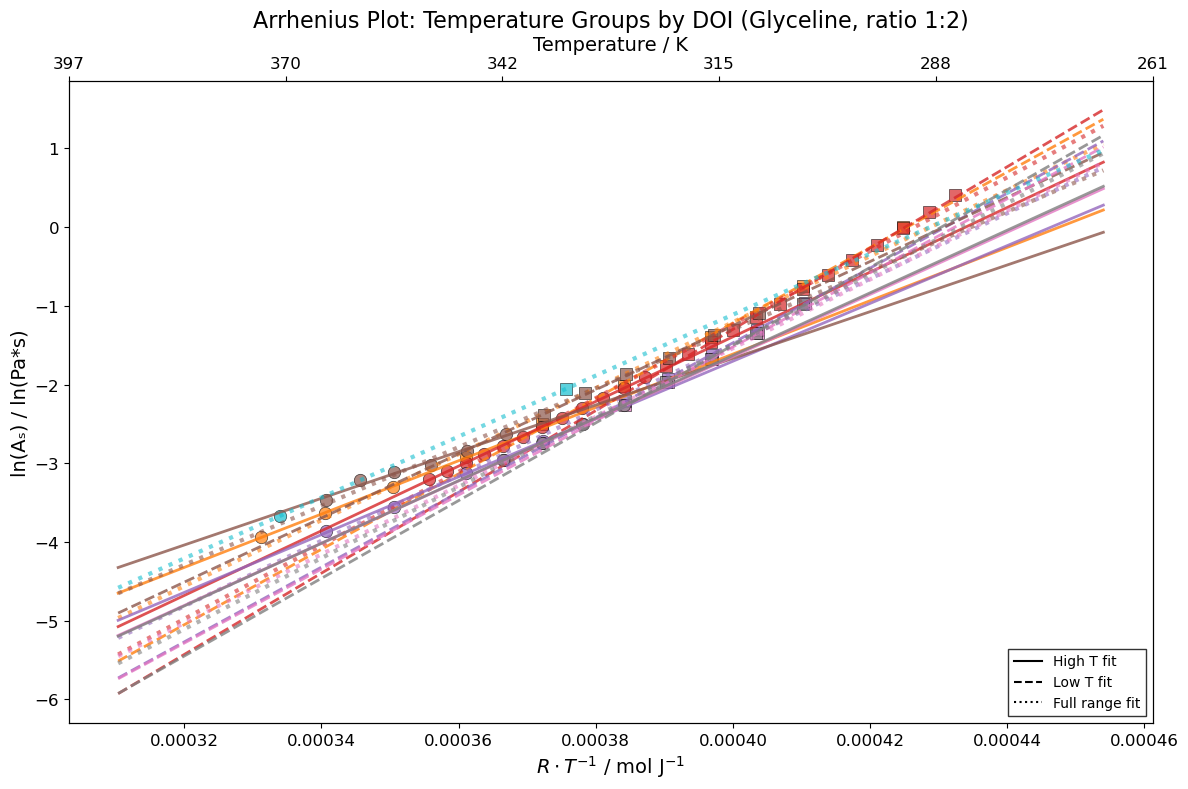

Split points DataFrame shape: (72, 27)

Temperature group distribution:
temperature_group
Low T     38
High T    34
Name: count, dtype: int64


,fluid_compounds,property_type,property_value,uncertainty,temperature,mole_fractions,measurement_id,source_doi,Mole fraction,Temperature,...,density_uncertainty,thermalConductivity_value,thermalConductivity_uncertainty,viscosity_value,viscosity_uncertainty,mole_fraction_water,inv_RT,ln_viscosity,ln_viscosity_scaled,temperature_group
0,"[Choline Chloride, Glycerol]",viscosity,0.019587,0.000098,363.15,"[0.333333333333, 0.666666666667]",3686859c-22ea-49dd-ac42-d40dc820dae3,10.1016/j.fluid.2014.01.028,0.666667,363.15,...,None,None,None,0.019587,0.000098,0.0,0.000331,-3.932910,-10.840665,High T
1,"[Choline Chloride, Glycerol]",viscosity,0.026333,0.000132,353.15,"[0.333333333333, 0.666666666667]",a468acdb-b7ac-431a-958a-a5f25ba790e6,10.1016/j.fluid.2014.01.028,0.666667,353.15,...,None,None,None,0.026333,0.000132,0.0,0.000341,-3.636929,-10.544684,High T
2,"[Choline Chloride, Glycerol]",viscosity,0.036741,0.000184,343.15,"[0.333333333333, 0.666666666667]",2b9710af-231e-434c-a47a-304f8409a8a3,10.1016/j.fluid.2014.01.028,0.666667,343.15,...,None,None,None,0.036741,0.000184,0.0,0.000350,-3.303865,-10.211620,High T
3,"[Choline Chloride, Glycerol]",viscosity,0.053812,0.000269,333.15,"[0.333333333333, 0.666666666667]",291df303-fa79-4ef4-86ca-2d526c8555bb,10.1016/j.fluid.2014.01.028,0.666667,333.15,...,None,None,None,0.053812,0.000269,0.0,0.000361,-2.922264,-9.830020,High T
4,"[Choline Chloride, Glycerol]",viscosity,0.081589,0.000408,323.15,"[0.333333333333, 0.666666666667]",08fb09d4-ba02-487e-a55a-f6489894e054,10.1016/j.fluid.2014.01.028,0.666667,323.15,...,None,None,None,0.081589,0.000408,0.0,0.000372,-2.506055,-9.413810,Low T
5,"[Choline Chloride, Glycerol]",viscosity,0.133375,0.000667,313.15,"[0.333333333333, 0.666666666667]",7c1e9f13-03c7-4e75-bb4e-0787c75931d5,10.1016/j.fluid.2014.01.028,0.666667,313.15,...,None,None,None,0.133375,0.000667,0.0,0.000384,-2.014591,-8.922347,Low T
6,"[Choline Chloride, Glycerol]",viscosity,0.246793,0.001234,303.15,"[0.333333333333, 0.666666666667]",5903da59-4132-4c2e-8ced-3b10ab752b3c,10.1016/j.fluid.2014.01.028,0.666667,303.15,...,None,None,None,0.246793,0.001234,0.0,0.000397,-1.399206,-8.306961,Low T
7,"[Choline Chloride, Glycerol]",viscosity,0.472967,0.002365,293.15,"[0.333333333333, 0.666666666667]",00d9c3d5-d0a9-453a-ab35-01427e57dc16,10.1016/j.fluid.2014.01.028,0.666667,293.15,...,None,None,None,0.472967,0.002365,0.0,0.000410,-0.748729,-7.656485,Low T
8,"[Choline Chloride, Glycerol]",viscosity,1.003943,0.005020,283.15,"[0.333333333333, 0.666666666667]",f44ddacb-3cb3-48c5-9e4d-04a7d54a512f,10.1016/j.fluid.2014.01.028,0.666667,283.15,...,None,None,None,1.003943,0.00502,0.0,0.000425,0.003935,-6.903820,Low T
9,"[Choline Chloride, Glycerol]",viscosity,0.040940,0.000819,338.15,"[0.333333333333, 0.666666666667]",51ebe2af-85f0-47c3-b731-88c90797a1a9,10.1016/j.jct.2018.07.031,0.666667,338.15,...,None,None,None,0.04094,0.000819,0.0,0.000356,-3.195648,-10.103403,High T


In [37]:
# Plot filtered_df grouped by DOI, splitting temperature points into low and high temperature groups
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 8))

# Get unique DOIs
dois = filtered_df['source_doi'].unique()

# Color map for DOIs
colors = plt.cm.tab10(np.linspace(0, 1, len(dois)))
color_map = dict(zip(dois, colors))

# List to store all split data
split_data = []

# Get overall x-axis range for extending lines
all_inv_RT = filtered_df[~filtered_df["inv_RT"].isna()]["inv_RT"]
x_range_min = all_inv_RT.min() * 0.95
x_range_max = all_inv_RT.max() * 1.05

# Process each DOI
for i, doi in enumerate(dois):
    subset = filtered_df[
        (filtered_df["source_doi"] == doi)
        & (~filtered_df["inv_RT"].isna())
        & (~filtered_df["ln_viscosity"].isna())
    ]
    
    if len(subset) < 2:
        continue  # Skip if not enough points
    
    # Sort by temperature (inverse of inv_RT for proper ordering)
    subset_sorted = subset.sort_values('inv_RT')
    
    # Split into two halves based on temperature
    n_points = len(subset_sorted)
    mid_point = n_points // 2
    
    # Lower half (higher temperatures - lower inv_RT values)
    low_temp_group = subset_sorted.iloc[:mid_point].copy()
    low_temp_group['temperature_group'] = 'High T'
    
    # Upper half (lower temperatures - higher inv_RT values)  
    high_temp_group = subset_sorted.iloc[mid_point:].copy()
    high_temp_group['temperature_group'] = 'Low T'
    
    # Add to split_data list
    split_data.append(low_temp_group)
    split_data.append(high_temp_group)
    
    # Plot low temperature group (circles)
    if len(low_temp_group) > 0:
        ax.scatter(
            low_temp_group["inv_RT"],
            low_temp_group["ln_viscosity"],
            label=f'{doi} (High T)',
            color=color_map[doi],
            marker='o',
            s=80,
            alpha=0.7,
            edgecolor='black',
            linewidth=0.5
        )
        
        # Fit and plot extended Arrhenius line for high temperature group
        if len(low_temp_group) >= 2:
            x_high = low_temp_group["inv_RT"].values
            y_high = low_temp_group["ln_viscosity"].values
            slope_high, intercept_high = np.polyfit(x_high, y_high, 1)
            
            # Create extended line points for plotting
            x_line_high = np.linspace(x_range_min, x_range_max, 100)
            y_line_high = slope_high * x_line_high + intercept_high
            
            ax.plot(x_line_high, y_line_high, color=color_map[doi], 
                   linestyle='-', alpha=0.8, linewidth=2)
    
    # Plot high temperature group (squares)
    if len(high_temp_group) > 0:
        ax.scatter(
            high_temp_group["inv_RT"],
            high_temp_group["ln_viscosity"],
            label=f'{doi} (Low T)',
            color=color_map[doi],
            marker='s',
            s=80,
            alpha=0.7,
            edgecolor='black',
            linewidth=0.5
        )
        
        # Fit and plot extended Arrhenius line for low temperature group
        if len(high_temp_group) >= 2:
            x_low = high_temp_group["inv_RT"].values
            y_low = high_temp_group["ln_viscosity"].values
            slope_low, intercept_low = np.polyfit(x_low, y_low, 1)
            
            # Create extended line points for plotting
            x_line_low = np.linspace(x_range_min, x_range_max, 100)
            y_line_low = slope_low * x_line_low + intercept_low
            
            ax.plot(x_line_low, y_line_low, color=color_map[doi], 
                   linestyle='--', alpha=0.8, linewidth=2)
    
    # Plot extended full range Arrhenius line
    if len(subset_sorted) >= 2:
        x_full = subset_sorted["inv_RT"].values
        y_full = subset_sorted["ln_viscosity"].values
        slope_full, intercept_full = np.polyfit(x_full, y_full, 1)
        
        # Create extended line points for plotting
        x_line_full = np.linspace(x_range_min, x_range_max, 100)
        y_line_full = slope_full * x_line_full + intercept_full
        
        ax.plot(x_line_full, y_line_full, color=color_map[doi], 
               linestyle=':', alpha=0.6, linewidth=3)

# Set labels and title
ax.set_xlabel('$R \cdot T^{-1}$ / mol J$^{-1}$', fontsize=14)
ax.set_ylabel('ln(Aₛ) / ln(Pa*s)', fontsize=14)
ax.set_title('Arrhenius Plot: Temperature Groups by DOI (Glyceline, ratio 1:2)', fontsize=16)

# Increase tick label font size
ax.tick_params(axis='both', which='major', labelsize=12)

# Create secondary x-axis for temperature
ax_temp = ax.twiny()

# Get the current x-axis limits
x_min, x_max = ax.get_xlim()

# Convert 1/(R*T) to temperature (K)
R = 8.314462618  # J/mol/K
T_min = 1 / (R * x_max)  # Higher 1/(R*T) corresponds to lower temperature
T_max = 1 / (R * x_min)  # Lower 1/(R*T) corresponds to higher temperature

# Set temperature axis limits and ticks
ax_temp.set_xlim(T_max, T_min)
temp_ticks = np.linspace(T_max, T_min, 6)
ax_temp.set_xticks(temp_ticks)
ax_temp.set_xticklabels([f'{T:.0f}' for T in temp_ticks])
ax_temp.set_xlabel('Temperature / K', fontsize=14)
ax_temp.tick_params(axis='x', which='major', labelsize=12)

# Create legend with two columns to accommodate more entries
legend = ax.legend(bbox_to_anchor=(1.04, 1), loc='upper left', frameon=True, 
                  fancybox=False, fontsize=10, ncol=1)
if legend is not None:
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('black')

# Add legend for line styles
from matplotlib.lines import Line2D
line_legend_elements = [
    Line2D([0], [0], color='black', linestyle='-', label='High T fit'),
    Line2D([0], [0], color='black', linestyle='--', label='Low T fit'),
    Line2D([0], [0], color='black', linestyle=':', label='Full range fit')
]
line_legend = ax.legend(handles=line_legend_elements, loc='lower right', 
                       frameon=True, fancybox=False, fontsize=10)
line_legend.get_frame().set_facecolor('white')
line_legend.get_frame().set_edgecolor('black')

# Add the original legend back
ax.add_artist(legend)

plt.tight_layout()
save_plot_as_svg()
plt.show()

# Combine all split data into a single DataFrame
split_points_df = pd.concat(split_data, ignore_index=True)

print(f"Split points DataFrame shape: {split_points_df.shape}")
print("\nTemperature group distribution:")
print(split_points_df['temperature_group'].value_counts())
display(split_points_df.head(10))


✓ Plot gespeichert: image_output/Arrhenius_Plots_Temperature_Groups_by_DOI_Glycelin_19.svg (238,357 Bytes)


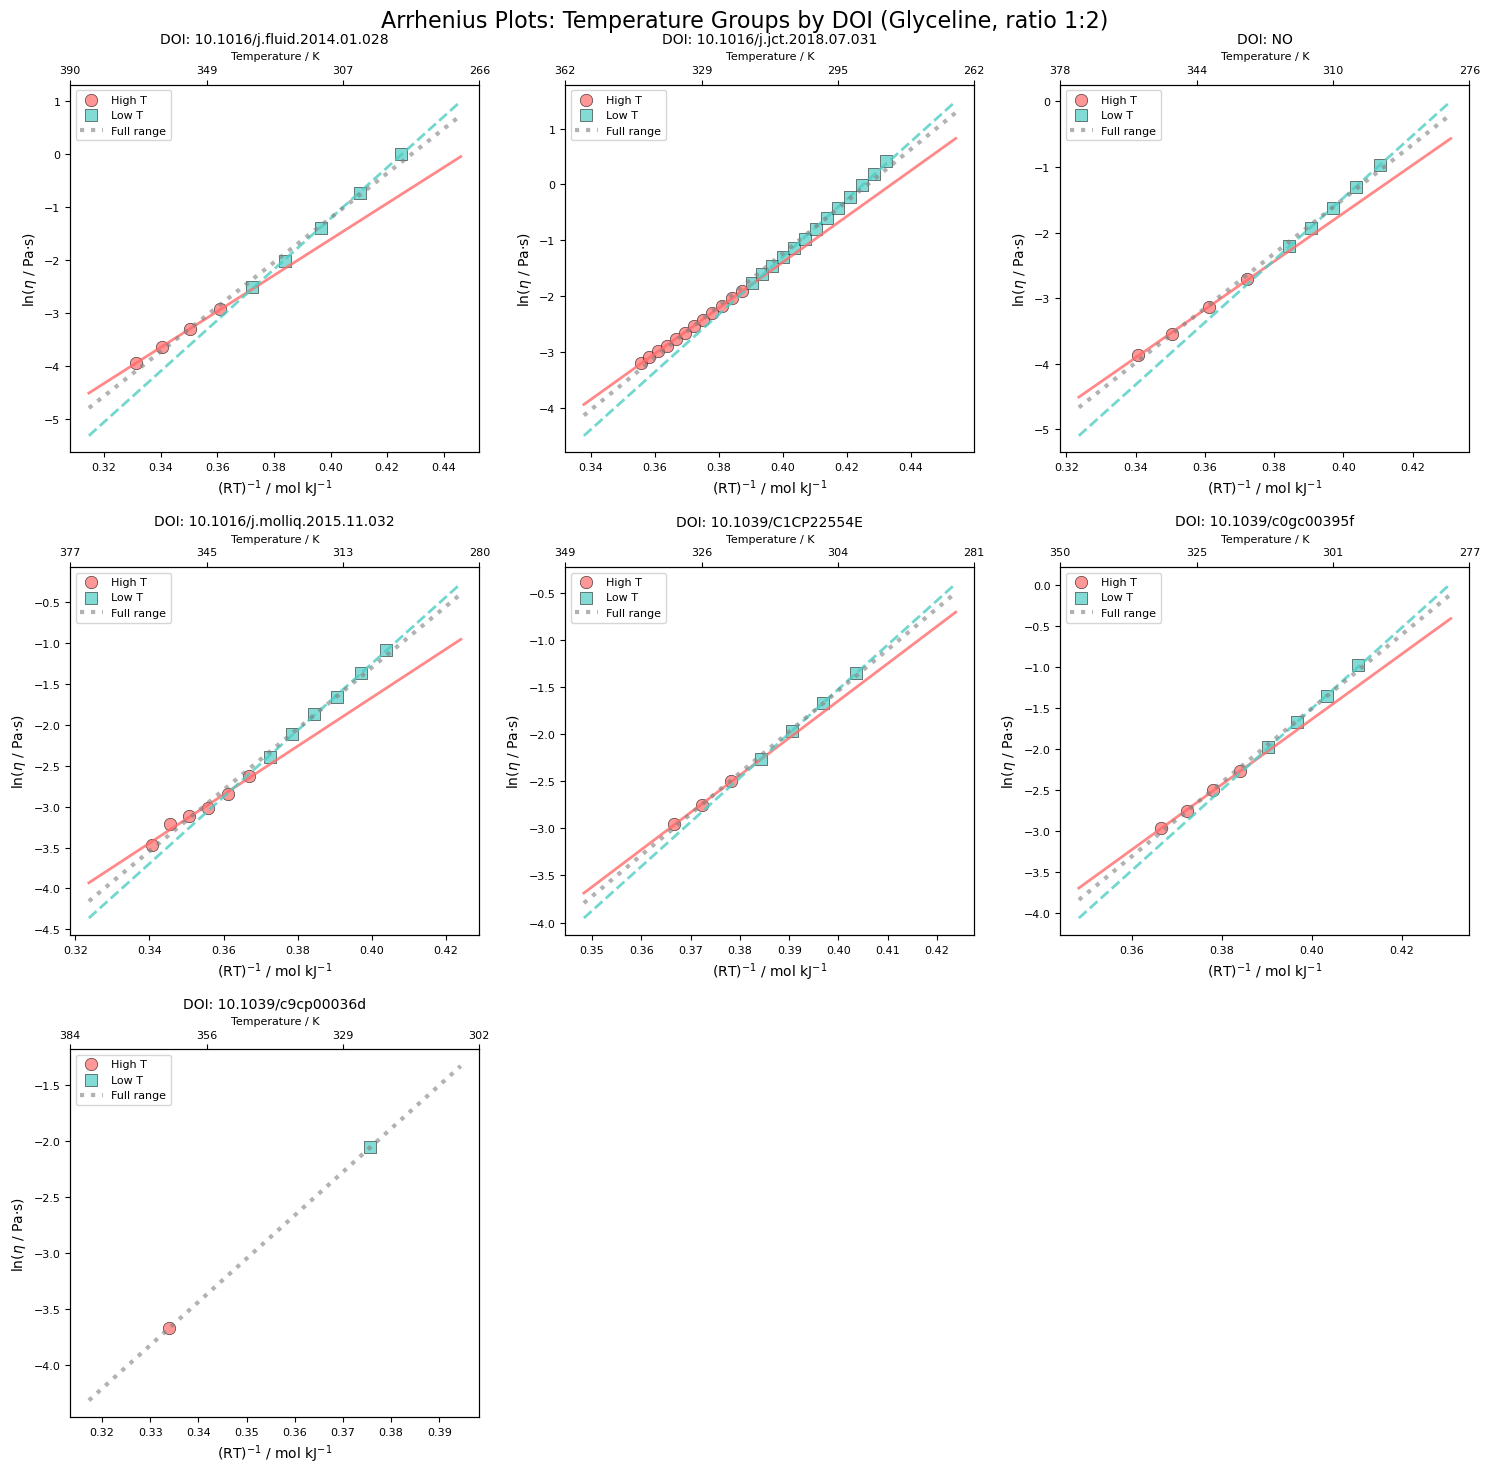

Split points DataFrame shape: (72, 27)

Temperature group distribution:
temperature_group
Low T     38
High T    34
Name: count, dtype: int64


,fluid_compounds,property_type,property_value,uncertainty,temperature,mole_fractions,measurement_id,source_doi,Mole fraction,Temperature,...,density_uncertainty,thermalConductivity_value,thermalConductivity_uncertainty,viscosity_value,viscosity_uncertainty,mole_fraction_water,inv_RT,ln_viscosity,ln_viscosity_scaled,temperature_group
0,"[Choline Chloride, Glycerol]",viscosity,0.019587,0.000098,363.15,"[0.333333333333, 0.666666666667]",3686859c-22ea-49dd-ac42-d40dc820dae3,10.1016/j.fluid.2014.01.028,0.666667,363.15,...,None,None,None,0.019587,0.000098,0.0,0.000331,-3.932910,-10.840665,High T
1,"[Choline Chloride, Glycerol]",viscosity,0.026333,0.000132,353.15,"[0.333333333333, 0.666666666667]",a468acdb-b7ac-431a-958a-a5f25ba790e6,10.1016/j.fluid.2014.01.028,0.666667,353.15,...,None,None,None,0.026333,0.000132,0.0,0.000341,-3.636929,-10.544684,High T
2,"[Choline Chloride, Glycerol]",viscosity,0.036741,0.000184,343.15,"[0.333333333333, 0.666666666667]",2b9710af-231e-434c-a47a-304f8409a8a3,10.1016/j.fluid.2014.01.028,0.666667,343.15,...,None,None,None,0.036741,0.000184,0.0,0.000350,-3.303865,-10.211620,High T
3,"[Choline Chloride, Glycerol]",viscosity,0.053812,0.000269,333.15,"[0.333333333333, 0.666666666667]",291df303-fa79-4ef4-86ca-2d526c8555bb,10.1016/j.fluid.2014.01.028,0.666667,333.15,...,None,None,None,0.053812,0.000269,0.0,0.000361,-2.922264,-9.830020,High T
4,"[Choline Chloride, Glycerol]",viscosity,0.081589,0.000408,323.15,"[0.333333333333, 0.666666666667]",08fb09d4-ba02-487e-a55a-f6489894e054,10.1016/j.fluid.2014.01.028,0.666667,323.15,...,None,None,None,0.081589,0.000408,0.0,0.000372,-2.506055,-9.413810,Low T
5,"[Choline Chloride, Glycerol]",viscosity,0.133375,0.000667,313.15,"[0.333333333333, 0.666666666667]",7c1e9f13-03c7-4e75-bb4e-0787c75931d5,10.1016/j.fluid.2014.01.028,0.666667,313.15,...,None,None,None,0.133375,0.000667,0.0,0.000384,-2.014591,-8.922347,Low T
6,"[Choline Chloride, Glycerol]",viscosity,0.246793,0.001234,303.15,"[0.333333333333, 0.666666666667]",5903da59-4132-4c2e-8ced-3b10ab752b3c,10.1016/j.fluid.2014.01.028,0.666667,303.15,...,None,None,None,0.246793,0.001234,0.0,0.000397,-1.399206,-8.306961,Low T
7,"[Choline Chloride, Glycerol]",viscosity,0.472967,0.002365,293.15,"[0.333333333333, 0.666666666667]",00d9c3d5-d0a9-453a-ab35-01427e57dc16,10.1016/j.fluid.2014.01.028,0.666667,293.15,...,None,None,None,0.472967,0.002365,0.0,0.000410,-0.748729,-7.656485,Low T
8,"[Choline Chloride, Glycerol]",viscosity,1.003943,0.005020,283.15,"[0.333333333333, 0.666666666667]",f44ddacb-3cb3-48c5-9e4d-04a7d54a512f,10.1016/j.fluid.2014.01.028,0.666667,283.15,...,None,None,None,1.003943,0.00502,0.0,0.000425,0.003935,-6.903820,Low T
9,"[Choline Chloride, Glycerol]",viscosity,0.040940,0.000819,338.15,"[0.333333333333, 0.666666666667]",51ebe2af-85f0-47c3-b731-88c90797a1a9,10.1016/j.jct.2018.07.031,0.666667,338.15,...,None,None,None,0.04094,0.000819,0.0,0.000356,-3.195648,-10.103403,High T


In [38]:
# Plot filtered_df grouped by DOI, splitting temperature points into low and high temperature groups
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Get unique DOIs
dois = filtered_df['source_doi'].unique()

# Filter out DOIs with insufficient data first
valid_dois = []
for doi in dois:
    subset = filtered_df[
        (filtered_df["source_doi"] == doi)
        & (~filtered_df["inv_RT"].isna())
        & (~filtered_df["ln_viscosity"].isna())
    ]
    if len(subset) >= 2:
        valid_dois.append(doi)

# Calculate number of subplots needed
n_dois = len(valid_dois)
n_cols = 3  # Number of columns
n_rows = (n_dois + n_cols - 1) // n_cols  # Ceiling division

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

# Flatten axes array for easier indexing
if n_rows == 1:
    axes = [axes] if n_cols == 1 else axes
else:
    axes = axes.flatten()

# Color map for temperature groups
temp_colors = {'High T': '#FF6B6B', 'Low T': '#4ECDC4'}

# List to store all split data
split_data = []

# Process each valid DOI
for i, doi in enumerate(valid_dois):
    ax = axes[i]
    
    subset = filtered_df[
        (filtered_df["source_doi"] == doi)
        & (~filtered_df["inv_RT"].isna())
        & (~filtered_df["ln_viscosity"].isna())
    ]
    
    # Sort by temperature (inverse of inv_RT for proper ordering)
    subset_sorted = subset.sort_values('inv_RT')
    
    # Split into two halves based on temperature
    n_points = len(subset_sorted)
    mid_point = n_points // 2
    
    # Lower half (higher temperatures - lower inv_RT values)
    low_temp_group = subset_sorted.iloc[:mid_point].copy()
    low_temp_group['temperature_group'] = 'High T'
    
    # Upper half (lower temperatures - higher inv_RT values)  
    high_temp_group = subset_sorted.iloc[mid_point:].copy()
    high_temp_group['temperature_group'] = 'Low T'
    
    # Add to split_data list
    split_data.append(low_temp_group)
    split_data.append(high_temp_group)
    
    # Get x-axis range for extending lines (scaled by 1000)
    x_range_min = subset_sorted["inv_RT"].min() * 1000 * 0.95
    x_range_max = subset_sorted["inv_RT"].max() * 1000 * 1.05
    
    # Plot high temperature group (circles) - scale x-axis by 1000
    if len(low_temp_group) > 0:
        ax.scatter(
            low_temp_group["inv_RT"] * 1000,
            low_temp_group["ln_viscosity"],
            label='High T',
            color=temp_colors['High T'],
            marker='o',
            s=80,
            alpha=0.7,
            edgecolor='black',
            linewidth=0.5
        )
        
        # Fit and plot extended Arrhenius line for high temperature group
        if len(low_temp_group) >= 2:
            x_high = low_temp_group["inv_RT"].values
            y_high = low_temp_group["ln_viscosity"].values
            slope_high, intercept_high = np.polyfit(x_high, y_high, 1)
            
            # Create extended line points for plotting (scaled by 1000)
            x_line_high = np.linspace(x_range_min, x_range_max, 100)
            y_line_high = slope_high * (x_line_high / 1000) + intercept_high
            
            ax.plot(x_line_high, y_line_high, color=temp_colors['High T'], 
                   linestyle='-', alpha=0.8, linewidth=2)
    
    # Plot low temperature group (squares) - scale x-axis by 1000
    if len(high_temp_group) > 0:
        ax.scatter(
            high_temp_group["inv_RT"] * 1000,
            high_temp_group["ln_viscosity"],
            label='Low T',
            color=temp_colors['Low T'],
            marker='s',
            s=80,
            alpha=0.7,
            edgecolor='black',
            linewidth=0.5
        )
        
        # Fit and plot extended Arrhenius line for low temperature group
        if len(high_temp_group) >= 2:
            x_low = high_temp_group["inv_RT"].values
            y_low = high_temp_group["ln_viscosity"].values
            slope_low, intercept_low = np.polyfit(x_low, y_low, 1)
            
            # Create extended line points for plotting (scaled by 1000)
            x_line_low = np.linspace(x_range_min, x_range_max, 100)
            y_line_low = slope_low * (x_line_low / 1000) + intercept_low
            
            ax.plot(x_line_low, y_line_low, color=temp_colors['Low T'], 
                   linestyle='--', alpha=0.8, linewidth=2)
    
    # Plot extended full range Arrhenius line
    if len(subset_sorted) >= 2:
        x_full = subset_sorted["inv_RT"].values
        y_full = subset_sorted["ln_viscosity"].values
        slope_full, intercept_full = np.polyfit(x_full, y_full, 1)
        
        # Create extended line points for plotting (scaled by 1000)
        x_line_full = np.linspace(x_range_min, x_range_max, 100)
        y_line_full = slope_full * (x_line_full / 1000) + intercept_full
        
        ax.plot(x_line_full, y_line_full, color='gray', 
               linestyle=':', alpha=0.6, linewidth=3, label='Full range')
    
    # Set labels and title for each subplot
    ax.set_xlabel(r'(RT)$^{-1}$ / mol kJ$^{-1}$', fontsize=10)
    ax.set_ylabel(r'ln($\eta$ / Pa$\cdot$s)', fontsize=10)
    ax.set_title(f'DOI: {doi}', fontsize=10, wrap=True)
    
    # Add legend to each subplot
    ax.legend(fontsize=8, loc='best')
    
    # Increase tick label font size
    ax.tick_params(axis='both', which='major', labelsize=8)
    
    # Create secondary x-axis for temperature
    ax_temp = ax.twiny()
    
    # Get the current x-axis limits (already scaled by 1000)
    x_min, x_max = ax.get_xlim()
    
    # Convert 1/(R*T) to temperature (K) - need to divide by 1000 first
    R = 8.314462618  # J/mol/K
    T_min = 1 / (R * (x_max / 1000))  # Higher 1/(R*T) corresponds to lower temperature
    T_max = 1 / (R * (x_min / 1000))  # Lower 1/(R*T) corresponds to higher temperature
    
    # Set temperature axis limits and ticks
    ax_temp.set_xlim(T_max, T_min)
    temp_ticks = np.linspace(T_max, T_min, 4)  # Fewer ticks for smaller plots
    ax_temp.set_xticks(temp_ticks)
    ax_temp.set_xticklabels([f'{T:.0f}' for T in temp_ticks], fontsize=8)
    ax_temp.set_xlabel('Temperature / K', fontsize=8)
    ax_temp.tick_params(axis='x', which='major', labelsize=8)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Add overall title
fig.suptitle('Arrhenius Plots: Temperature Groups by DOI (Glyceline, ratio 1:2)', 
             fontsize=16, y=0.98)

plt.tight_layout()
save_plot_as_svg()
plt.show()

# Combine all split data into a single DataFrame
split_points_df = pd.concat(split_data, ignore_index=True)

print(f"Split points DataFrame shape: {split_points_df.shape}")
print("\nTemperature group distribution:")
print(split_points_df['temperature_group'].value_counts())
display(split_points_df.head(10))


In [39]:
# Calculate activation energy (E_a) for each DOI and temperature group combination from the split points
# ln(viscosity) = ln(A) + E_a / R * (1/T)
# So: slope = E_a / R  =>  E_a = slope * R

import numpy as np

R = 8.314462618  # J/mol/K (universal gas constant)

group_activation_energies = []

# Filter for glyceline mixtures only (no water) - mole_fraction_water should be 0.0
glyceline_data = split_points_df[split_points_df['mole_fraction_water'] == 0.0]

# Get unique combinations of DOI and temperature group for glyceline only
doi_temp_combinations = glyceline_data[['source_doi', 'temperature_group']].drop_duplicates()

for _, row in doi_temp_combinations.iterrows():
    doi = row['source_doi']
    temp_group = row['temperature_group']
    
    subset = glyceline_data[
        (glyceline_data['source_doi'] == doi) & 
        (glyceline_data['temperature_group'] == temp_group)
    ]
    
    if len(subset) < 2:
        continue  # Not enough points to fit
    
    # Calculate temperature range for this subset
    temp_min = subset['temperature'].min()
    temp_max = subset['temperature'].max()
    temp_range = f"{temp_min:.0f}-{temp_max:.0f}"
    
    # Fit: ln(viscosity) = slope * inv_RT + intercept
    # NOTE: inv_RT is already 1/(R*T), so slope directly gives E_a in J/mol
    x = subset["inv_RT"].values
    y = subset["ln_viscosity"].values
    
    # Check for outliers or unreasonable data points
    print(f"DOI: {doi}, Group: {temp_group}")
    print(f"  Temperature range: {temp_range} K")
    print(f"  inv_RT range: {x.min():.6f} to {x.max():.6f}")
    print(f"  ln(viscosity) range: {y.min():.3f} to {y.max():.3f}")
    
    # np.polyfit returns [slope, intercept]
    slope, intercept = np.polyfit(x, y, 1)
    # Since inv_RT = 1/(R*T), the slope is already E_a in J/mol (no need to multiply by R)
    E_a = slope  # activation energy in J/mol
    E_a_kJ_per_mol = E_a / 1000  # Convert to kJ/mol for easier interpretation
    
    print(f"  Slope: {slope:.1f}, E_a: {E_a_kJ_per_mol:.1f} kJ/mol")
    
    # Calculate R-squared for goodness of fit
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    
    group_activation_energies.append({
        "source_doi": doi,
        "temperature_group": temp_group,
        "temperature_range": temp_range,
        "activation_energy_J_per_mol": E_a,
        "activation_energy_kJ_per_mol": E_a_kJ_per_mol,
        "arrhenius_prefactor_lnA": intercept,
        "r_squared": r_squared,
        "n_points": len(subset)
    })
    print()

# Also calculate activation energy for full temperature range for each DOI (glyceline only)
unique_dois = glyceline_data['source_doi'].unique()

for doi in unique_dois:
    subset = glyceline_data[glyceline_data['source_doi'] == doi]
    
    if len(subset) < 2:
        continue  # Not enough points to fit
    
    # Calculate temperature range for this subset
    temp_min = subset['temperature'].min()
    temp_max = subset['temperature'].max()
    temp_range = f"{temp_min:.0f}-{temp_max:.0f}"
    
    # Fit: ln(viscosity) = slope * inv_RT + intercept
    x = subset["inv_RT"].values
    y = subset["ln_viscosity"].values
    
    print(f"DOI: {doi}, Full Range")
    print(f"  Temperature range: {temp_range} K")
    print(f"  inv_RT range: {x.min():.6f} to {x.max():.6f}")
    print(f"  ln(viscosity) range: {y.min():.3f} to {y.max():.3f}")
    
    # np.polyfit returns [slope, intercept]
    slope, intercept = np.polyfit(x, y, 1)
    # Since inv_RT = 1/(R*T), the slope is already E_a in J/mol (no need to multiply by R)
    E_a = slope  # activation energy in J/mol
    E_a_kJ_per_mol = E_a / 1000  # Convert to kJ/mol for easier interpretation
    
    print(f"  Slope: {slope:.1f}, E_a: {E_a_kJ_per_mol:.1f} kJ/mol")
    
    # Calculate R-squared for goodness of fit
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    
    group_activation_energies.append({
        "source_doi": doi,
        "temperature_group": "Full Range",
        "temperature_range": temp_range,
        "activation_energy_J_per_mol": E_a,
        "activation_energy_kJ_per_mol": E_a_kJ_per_mol,
        "arrhenius_prefactor_lnA": intercept,
        "r_squared": r_squared,
        "n_points": len(subset)
    })
    print()

# Convert to DataFrame for summary display
group_activation_energy_df = pd.DataFrame(group_activation_energies)

print("Activation energies (E_a) and Arrhenius prefactor by DOI and temperature group (Glyceline Only - No Water):")
print("Note: Typical activation energies for viscous flow are 10-100 kJ/mol")
display(group_activation_energy_df)


DOI: 10.1016/j.fluid.2014.01.028, Group: High T
  Temperature range: 333-363 K
  inv_RT range: 0.000331 to 0.000361
  ln(viscosity) range: -3.933 to -2.922
  Slope: 33881.7, E_a: 33.9 kJ/mol

DOI: 10.1016/j.fluid.2014.01.028, Group: Low T
  Temperature range: 283-323 K
  inv_RT range: 0.000372 to 0.000425
  ln(viscosity) range: -2.506 to 0.004
  Slope: 47918.9, E_a: 47.9 kJ/mol

DOI: 10.1016/j.jct.2018.07.031, Group: High T
  Temperature range: 311-338 K
  inv_RT range: 0.000356 to 0.000387
  ln(viscosity) range: -3.196 to -1.904
  Slope: 41073.2, E_a: 41.1 kJ/mol

DOI: 10.1016/j.jct.2018.07.031, Group: Low T
  Temperature range: 278-308 K
  inv_RT range: 0.000390 to 0.000432
  ln(viscosity) range: -1.763 to 0.413
  Slope: 51631.2, E_a: 51.6 kJ/mol

DOI: NO, Group: High T
  Temperature range: 323-353 K
  inv_RT range: 0.000341 to 0.000372
  ln(viscosity) range: -3.862 to -2.714
  Slope: 36716.1, E_a: 36.7 kJ/mol

DOI: NO, Group: Low T
  Temperature range: 293-313 K
  inv_RT range: 0.00

,source_doi,temperature_group,temperature_range,activation_energy_J_per_mol,activation_energy_kJ_per_mol,arrhenius_prefactor_lnA,r_squared,n_points
0,10.1016/j.fluid.2014.01.028,High T,333-363,33881.699530,33.881700,-15.165900,0.999022,4
1,10.1016/j.fluid.2014.01.028,Low T,283-323,47918.947805,47.918948,-20.385919,0.998612,5
2,10.1016/j.jct.2018.07.031,High T,311-338,41073.168777,41.073169,-17.823342,0.999330,12
3,10.1016/j.jct.2018.07.031,Low T,278-308,51631.248713,51.631249,-21.951472,0.998993,13
4,NO,High T,323-353,36716.090607,36.716091,-16.390721,0.997996,4
5,NO,Low T,293-313,47488.465346,47.488465,-20.466047,0.999687,5
6,10.1016/j.molliq.2015.11.032,High T,328-353,29644.627352,29.644627,-13.525274,0.975107,6
7,10.1016/j.molliq.2015.11.032,Low T,298-323,40731.929070,40.731929,-17.545085,0.997972,6
8,10.1039/C1CP22554E,High T,318-328,39515.113405,39.515113,-17.451681,0.998239,3
9,10.1039/C1CP22554E,Low T,298-313,47033.702850,47.033703,-20.335841,0.999912,4


✓ Plot gespeichert: image_output/Activation_Energy_Comparison_by_DOI_and_Temperatur_20.svg (83,851 Bytes)


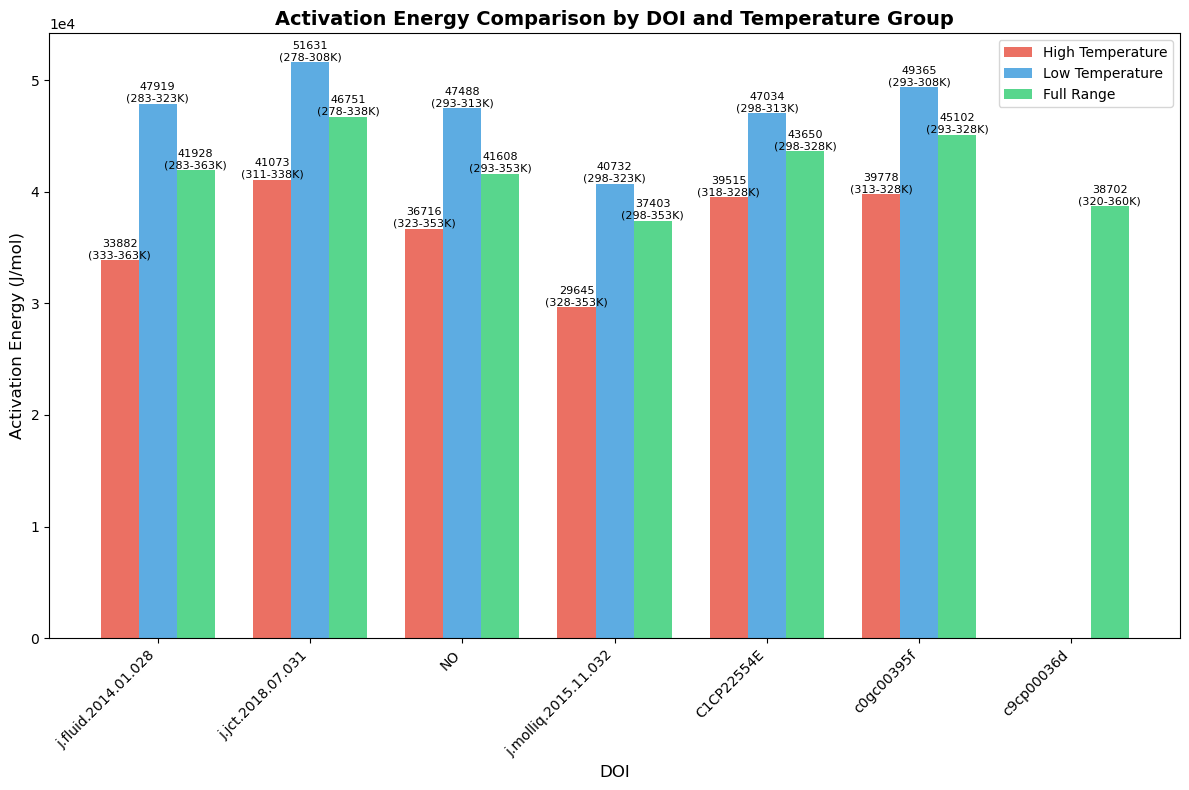


Activation Energy Differences by DOI:
j.fluid.2014.01.028:
  Low T (283-323K) - High T (333-363K): 14,037 J/mol (+41.4%)
  Full Range (283-363K) - High T (333-363K): 8,046 J/mol (+23.7%)
  Full Range (283-363K) - Low T (283-323K): -5,991 J/mol (-12.5%)

j.jct.2018.07.031:
  Low T (278-308K) - High T (311-338K): 10,558 J/mol (+25.7%)
  Full Range (278-338K) - High T (311-338K): 5,678 J/mol (+13.8%)
  Full Range (278-338K) - Low T (278-308K): -4,881 J/mol (-9.5%)

NO:
  Low T (293-313K) - High T (323-353K): 10,772 J/mol (+29.3%)
  Full Range (293-353K) - High T (323-353K): 4,892 J/mol (+13.3%)
  Full Range (293-353K) - Low T (293-313K): -5,880 J/mol (-12.4%)

j.molliq.2015.11.032:
  Low T (298-323K) - High T (328-353K): 11,087 J/mol (+37.4%)
  Full Range (298-353K) - High T (328-353K): 7,758 J/mol (+26.2%)
  Full Range (298-353K) - Low T (298-323K): -3,329 J/mol (-8.2%)

C1CP22554E:
  Low T (298-313K) - High T (318-328K): 7,519 J/mol (+19.0%)
  Full Range (298-328K) - High T (318-328K):

In [40]:
# Create a bar plot showing activation energy differences by DOI and temperature group
import matplotlib.pyplot as plt
import numpy as np

# Create the bar plot
fig, ax = plt.subplots(figsize=(12, 8))

# Get unique DOIs for grouping
unique_dois = group_activation_energy_df['source_doi'].unique()
n_dois = len(unique_dois)

# Set up bar positions
bar_width = 0.25
x_pos = np.arange(n_dois)

# Separate data by temperature group
high_t_data = []
low_t_data = []
full_range_data = []
doi_labels = []
high_t_ranges = []
low_t_ranges = []
full_ranges = []

for doi in unique_dois:
    doi_data = group_activation_energy_df[group_activation_energy_df['source_doi'] == doi]
    
    high_t = doi_data[doi_data['temperature_group'] == 'High T']
    low_t = doi_data[doi_data['temperature_group'] == 'Low T']
    full_range = doi_data[doi_data['temperature_group'] == 'Full Range']
    
    high_t_val = high_t['activation_energy_J_per_mol'].iloc[0] if len(high_t) > 0 else 0
    low_t_val = low_t['activation_energy_J_per_mol'].iloc[0] if len(low_t) > 0 else 0
    full_range_val = full_range['activation_energy_J_per_mol'].iloc[0] if len(full_range) > 0 else 0
    
    high_t_range = high_t['temperature_range'].iloc[0] if len(high_t) > 0 else ""
    low_t_range = low_t['temperature_range'].iloc[0] if len(low_t) > 0 else ""
    full_range_range = full_range['temperature_range'].iloc[0] if len(full_range) > 0 else ""
    
    high_t_data.append(high_t_val)
    low_t_data.append(low_t_val)
    full_range_data.append(full_range_val)
    high_t_ranges.append(high_t_range)
    low_t_ranges.append(low_t_range)
    full_ranges.append(full_range_range)
    
    # Create shorter labels for better readability
    short_doi = doi.split('/')[-1] if '/' in doi else doi
    doi_labels.append(short_doi)

# Create bars
bars1 = ax.bar(x_pos - bar_width, high_t_data, bar_width, 
               label='High Temperature', alpha=0.8, color='#E74C3C')
bars2 = ax.bar(x_pos, low_t_data, bar_width,
               label='Low Temperature', alpha=0.8, color='#3498DB')
bars3 = ax.bar(x_pos + bar_width, full_range_data, bar_width,
               label='Full Range', alpha=0.8, color='#2ECC71')

# Customize the plot
ax.set_xlabel('DOI', fontsize=12)
ax.set_ylabel('Activation Energy (J/mol)', fontsize=12)
ax.set_title('Activation Energy Comparison by DOI and Temperature Group', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(doi_labels, rotation=45, ha='right')
ax.legend()

# Add value labels on bars with temperature ranges
def add_value_labels_with_temp(bars, temp_ranges):
    for bar, temp_range in zip(bars, temp_ranges):
        height = bar.get_height()
        if height > 0:  # Only add label if there's a value
            label_text = f'{height:.0f}\n({temp_range}K)' if temp_range else f'{height:.0f}'
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   label_text,
                   ha='center', va='bottom', fontsize=8)

add_value_labels_with_temp(bars1, high_t_ranges)
add_value_labels_with_temp(bars2, low_t_ranges)
add_value_labels_with_temp(bars3, full_ranges)

# Format y-axis to show values in scientific notation
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
save_plot_as_svg()
plt.show()

# Calculate and display the differences
print("\nActivation Energy Differences by DOI:")
print("=" * 60)
for i, doi in enumerate(unique_dois):
    short_doi = doi_labels[i]
    print(f"{short_doi}:")
    
    if high_t_data[i] > 0 and low_t_data[i] > 0:
        diff_hl = low_t_data[i] - high_t_data[i]
        percent_diff_hl = (diff_hl / high_t_data[i]) * 100
        print(f"  Low T ({low_t_ranges[i]}K) - High T ({high_t_ranges[i]}K): {diff_hl:,.0f} J/mol ({percent_diff_hl:+.1f}%)")
    
    if full_range_data[i] > 0:
        if high_t_data[i] > 0:
            diff_fh = full_range_data[i] - high_t_data[i]
            percent_diff_fh = (diff_fh / high_t_data[i]) * 100
            print(f"  Full Range ({full_ranges[i]}K) - High T ({high_t_ranges[i]}K): {diff_fh:,.0f} J/mol ({percent_diff_fh:+.1f}%)")
        
        if low_t_data[i] > 0:
            diff_fl = full_range_data[i] - low_t_data[i]
            percent_diff_fl = (diff_fl / low_t_data[i]) * 100
            print(f"  Full Range ({full_ranges[i]}K) - Low T ({low_t_ranges[i]}K): {diff_fl:,.0f} J/mol ({percent_diff_fl:+.1f}%)")
    
    print()


In [41]:
# Calculate activation energy (E_a) for each DOI/series from the Arrhenius fit:
# ln(viscosity) = ln(A) + E_a / R * (1/T)
# So: slope = E_a / R  =>  E_a = slope * R
# We'll do this for each DOI/series in the filtered_df, using linear regression.

import numpy as np

R = 8.314462618  # J/mol/K (universal gas constant)

activation_energies = []

for doi in dois2:
    subset2 = filtered_df[
        (filtered_df["source_doi"] == doi)
        & (~filtered_df["inv_RT"].isna())
        & (~filtered_df["ln_viscosity"].isna())
    ]
    if len(subset2) < 2:
        continue  # Not enough points to fit
    # Fit: ln(viscosity) = slope * inv_RT + intercept
    x = subset2["inv_RT"].values
    y = subset2["ln_viscosity"].values
    # np.polyfit returns [slope, intercept]
    slope, intercept = np.polyfit(x, y, 1)
    E_a = slope * R  # activation energy in J/mol
    # Optional: y-intercept is ln(A), the Arrhenius prefactor
    activation_energies.append({
        "doi": doi,
        "activation_energy_J_per_mol": E_a,
        "arrhenius_prefactor_lnA": intercept
    })

# Convert activation energies to DataFrame for summary display
import pandas as pd
activation_energy_df = pd.DataFrame(activation_energies)

print("Activation energies (E_a) and Arrhenius prefactor by DOI (solvent ratio == 2):")
display(activation_energy_df)


Activation energies (E_a) and Arrhenius prefactor by DOI (solvent ratio == 2):


,doi,activation_energy_J_per_mol,arrhenius_prefactor_lnA
0,10.1016/j.fluid.2014.01.028,348607.692513,-17.979190
1,10.1016/j.jct.2018.07.031,388707.030266,-19.938777
2,NO,345951.349117,-18.131910
3,10.1016/j.molliq.2015.11.032,310986.610499,-16.260954
4,10.1039/C1CP22554E,362928.483901,-18.998364
5,10.1039/c0gc00395f,374999.279896,-19.540212
6,10.1039/c9cp00036d,321784.461947,-16.593692


/tmp/ipykernel_13941/246883716.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues', N)


✓ Plot gespeichert: image_output/Arrhenius_plot_of_Glyceline_with_different_water_m_21.svg (112,516 Bytes)


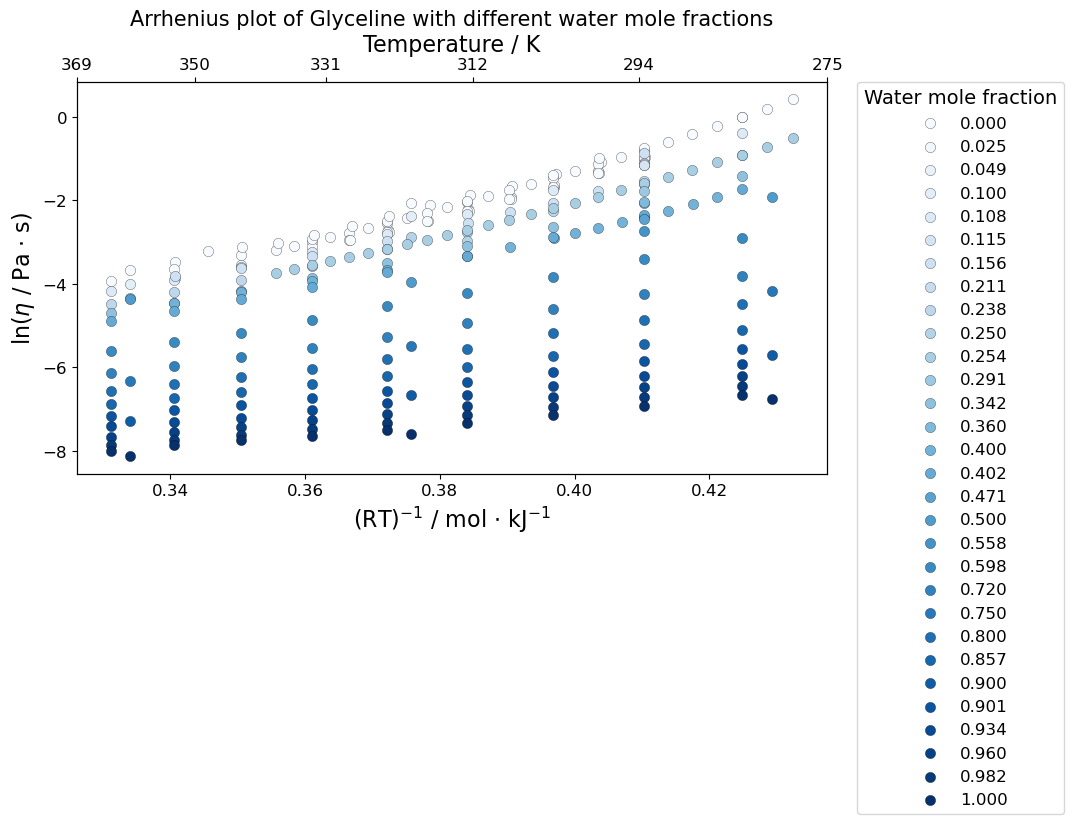

All linear fit activation energies by water mole fraction and source DOI, including ordinate and statistic:


,water_mole_fraction,activation_energy,source_doi,ordinate,statistic
0,0.000,41.606068,NO,-18.131910,0.998170
1,0.000,43.647835,10.1039/C1CP22554E,-18.998364,0.999017
2,0.000,37.401011,10.1016/j.molliq.2015.11.032,-16.260954,0.996212
3,0.000,46.748109,10.1016/j.jct.2018.07.031,-19.938777,0.998271
4,0.000,41.925535,10.1016/j.fluid.2014.01.028,-17.979190,0.996304
5,0.000,45.099537,10.1039/c0gc00395f,-19.540212,0.998521
6,0.000,38.699622,10.1039/c9cp00036d,-16.593692,1.000000
7,0.100,39.132853,10.1039/c9cp00036d,-17.079889,1.000000
8,0.108,40.366403,10.1016/j.fluid.2014.01.028,-17.714444,0.996411
9,0.156,38.285661,NO,-17.089777,0.969991


Saved activation energy data to 'df_data_glyceline_ratio_or_pure_water.csv'


In [42]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from scipy.stats import linregress

# Make sure required columns exist
required_cols = [
    "viscosity_value", 
    "temperature", 
    "source_doi", 
    "mole_fraction_water",
    "Solvent: Amount ratio of component to other component of binary solvent"
]
for col in required_cols:
    if col not in df_data_glyceline_ratio_or_pure_water.columns:
        raise ValueError(f"Column '{col}' not found in dataframe.")

# Filter on solvent ratio: keep rows where ratio <=2 or ratio is NaN (missing/None)
df_data_glyceline_ratio_or_pure_water_filtered = df_data_glyceline_ratio_or_pure_water[
    (df_data_glyceline_ratio_or_pure_water["Solvent: Amount ratio of component to other component of binary solvent"].isna()) |
    (df_data_glyceline_ratio_or_pure_water["Solvent: Amount ratio of component to other component of binary solvent"] <= 2)
].copy()

# Fill missing/None values in mole_fraction_water with 0
df_data_glyceline_ratio_or_pure_water_filtered["mole_fraction_water"] = (
    df_data_glyceline_ratio_or_pure_water_filtered["mole_fraction_water"]
    .fillna(0)
    .apply(lambda x: 0 if x is None else x)
)

# Clean for missing values in variables used
plot_df = df_data_glyceline_ratio_or_pure_water_filtered[
    df_data_glyceline_ratio_or_pure_water_filtered["viscosity_value"].notnull() &
    df_data_glyceline_ratio_or_pure_water_filtered["temperature"].notnull() &
    df_data_glyceline_ratio_or_pure_water_filtered["source_doi"].notnull()
].copy()

# Calculate ln(viscosity) and 1/(R*T)
R = 8.314  # J/(mol*K)
plot_df["inv_RT"] = 1000 / (R * plot_df["temperature"].astype(float))  # Factor 1000 for kJ instead of J
plot_df["ln_viscosity"] = np.log(plot_df["viscosity_value"].astype(float))

# Use mole_fraction_water to color the water amount
plot_df["water_mole_fraction"] = plot_df["mole_fraction_water"].astype(float)

# We'll use unique discrete values for water mole fraction as hue
plot_df["water_mole_fraction_rounded"] = plot_df["water_mole_fraction"].round(3)
discrete_mole_fractions = np.sort(plot_df["water_mole_fraction_rounded"].unique())

# Set up colormap: Blues colormap, N bins = number of unique mole fractions
N = len(discrete_mole_fractions)
cmap = cm.get_cmap('Blues', N)
color_dict = {mf: cmap(i) for i, mf in enumerate(discrete_mole_fractions)}

plt.figure(figsize=(11,7))
ax = plt.gca()

# Increase font size globally
plt.rcParams.update({'font.size': 14})

# Scatter points for each discrete fraction, so legend can be discrete
for i, mf in enumerate(discrete_mole_fractions):
    subset = plot_df[plot_df["water_mole_fraction_rounded"] == mf]
    ax.scatter(
        subset["inv_RT"], 
        subset["ln_viscosity"], 
        color=color_dict[mf],
        s=55, 
        edgecolor='black',
        linewidth=0.2,
        label=f"{mf:.3f}"
    )

# Linear fit and store slopes per discrete water content, including source_doi
slope_results = []
for mf in discrete_mole_fractions:
    group = plot_df[plot_df["water_mole_fraction_rounded"] == mf]
    # For each unique source_doi in this water content, do a fit for that subset
    for doi in group["source_doi"].unique():
        doi_group = group[group["source_doi"] == doi]
        if len(doi_group) >= 2:
            x = doi_group["inv_RT"].values
            y = doi_group["ln_viscosity"].values
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            xfit = np.linspace(x.min(), x.max(), 50)
            yfit = intercept + slope * xfit
            # Optionally: plot fits per color, commented
            # ax.plot(xfit, yfit, linestyle='--', linewidth=2, color=color_dict[mf])
            mf_tuple = (tuple(doi_group["mole_fractions"].iloc[0]) if "mole_fractions" in doi_group.columns and isinstance(doi_group["mole_fractions"].iloc[0], (list, tuple)) 
                        else doi_group["mole_fractions"].iloc[0] if "mole_fractions" in doi_group.columns else None)
            slope_results.append({
                "mole_fractions": mf_tuple,
                "water_mole_fraction": float(mf),
                "slope": slope,
                "source_doi": doi,
                "ordinate": intercept,
                "statistic": r_value
            })

# Create secondary x-axis for temperature
ax2 = ax.twiny()

# Get the range of 1/(R*T) values to create corresponding temperature values
inv_RT_min, inv_RT_max = ax.get_xlim()
T_max = 1000 / (R * inv_RT_min)  # Higher temperature corresponds to lower 1/(R*T), factor 1000 for kJ
T_min = 1000 / (R * inv_RT_max)  # Lower temperature corresponds to higher 1/(R*T), factor 1000 for kJ

# Set temperature ticks
temp_ticks = np.linspace(T_min, T_max, 6)  # 6 temperature points
inv_RT_ticks = 1000 / (R * temp_ticks)  # Factor 1000 for kJ

ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(inv_RT_ticks)
ax2.set_xticklabels([f'{T:.0f}' for T in temp_ticks])
ax2.set_xlabel('Temperature / K', fontsize=16)

# Make discrete legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
lgd = ax.legend(by_label.values(), by_label.keys(), title="Water mole fraction", bbox_to_anchor=(1.04, 1), loc='upper left', borderaxespad=0., fontsize=12)
lgd.get_title().set_fontsize(14)

plt.title('Arrhenius plot of Glyceline with different water mole fractions', fontsize=15)
ax.set_xlabel(r'(RT)$^{-1}$ / mol $\cdot$ kJ$^{-1}$', fontsize=16)
ax.set_ylabel(r'ln($\eta$ / Pa $\cdot$ s)', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='x', which='major', labelsize=12)
plt.tight_layout()
save_plot_as_svg()
plt.show()

import pandas as pd
activation_energy_df = pd.DataFrame(slope_results)
# Rename for clarity
activation_energy_df = activation_energy_df.rename(columns={'slope': 'activation_energy'})
# Ensure 'ordinate' and 'statistic' columns are present (they are, see above)
print("All linear fit activation energies by water mole fraction and source DOI, including ordinate and statistic:")
display(activation_energy_df[["water_mole_fraction", "activation_energy", "source_doi", "ordinate", "statistic"]])

activation_energy_df['measurement'] = 'measured'
activation_energy_df.to_csv('activation_energy_results_measured.csv', index=False)


# Add a column called 'measured' and fill it with 'measured'
df_data_glyceline_ratio_or_pure_water_filtered['measured'] = 'measured'

# Save the activation energy data to CSV
df_data_glyceline_ratio_or_pure_water_filtered.to_csv('df_data_glyceline_ratio_or_pure_water.csv', index=False)
print("Saved activation energy data to 'df_data_glyceline_ratio_or_pure_water.csv'")

<>:158: SyntaxWarning: invalid escape sequence '\e'
<>:158: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_13941/3599414777.py:158: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('ln($\eta$ / Pa$\cdot$s)', fontsize=16, color='#2C3E50')


✓ Plot gespeichert: image_output/Arrhenius_plot_of_Glyceline_with_different_water_m_22.svg (114,424 Bytes)


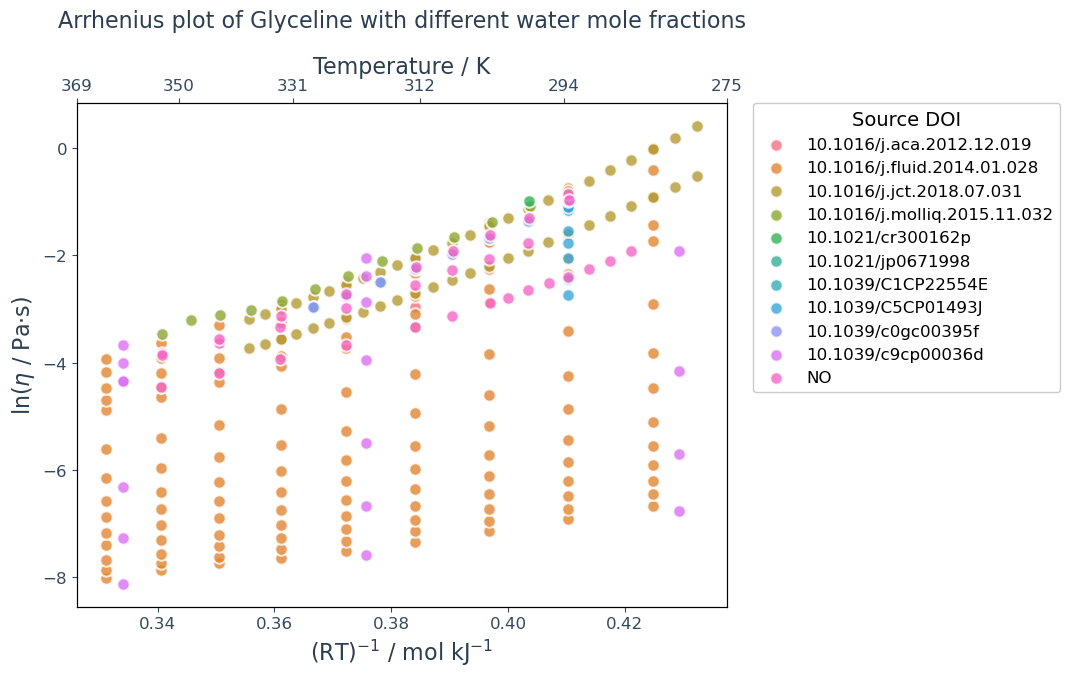

All linear fit activation energies by water mole fraction and source DOI, including ordinate and statistic:


,water_mole_fraction,activation_energy,source_doi,ordinate,statistic,color
0,0.000,41.606068,NO,-18.131910,0.998170,"(0.9628653850704804, 0.4025928454059796, 0.777..."
1,0.000,43.647835,10.1039/C1CP22554E,-18.998364,0.999017,"(0.21420912437215422, 0.6714963557258681, 0.69..."
2,0.000,37.401011,10.1016/j.molliq.2015.11.032,-16.260954,0.996212,"(0.5432776721247529, 0.6540981095185215, 0.193..."
3,0.000,46.748109,10.1016/j.jct.2018.07.031,-19.938777,0.998271,"(0.710130687316902, 0.6046852192663268, 0.1942..."
4,0.000,41.925535,10.1016/j.fluid.2014.01.028,-17.979190,0.996304,"(0.8836443049112893, 0.5240073524369634, 0.195..."
5,0.000,45.099537,10.1039/c0gc00395f,-19.540212,0.998521,"(0.5596943802099308, 0.5764402169887779, 0.958..."
6,0.000,38.699622,10.1039/c9cp00036d,-16.593692,1.000000,"(0.8578978803740233, 0.44058452715322166, 0.95..."
7,0.100,39.132853,10.1039/c9cp00036d,-17.079889,1.000000,"(0.8578978803740233, 0.44058452715322166, 0.95..."
8,0.108,40.366403,10.1016/j.fluid.2014.01.028,-17.714444,0.996411,"(0.8836443049112893, 0.5240073524369634, 0.195..."
9,0.156,38.285661,NO,-17.089777,0.969991,"(0.9628653850704804, 0.4025928454059796, 0.777..."


Saved activation energy data to 'df_data_glyceline_ratio_or_pure_water.csv'


In [43]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from scipy.stats import linregress
import seaborn as sns

# Set a beautiful color palette
plt.style.use('default')
sns.set_palette("husl")

# Make sure required columns exist
required_cols = [
    "viscosity_value", 
    "temperature", 
    "source_doi", 
    "mole_fraction_water",
    "Solvent: Amount ratio of component to other component of binary solvent"
]
for col in required_cols:
    if col not in df_data_glyceline_ratio_or_pure_water.columns:
        raise ValueError(f"Column '{col}' not found in dataframe.")

# Filter on solvent ratio: keep rows where ratio <=2 or ratio is NaN (missing/None)
df_data_glyceline_ratio_or_pure_water_filtered = df_data_glyceline_ratio_or_pure_water[
    (df_data_glyceline_ratio_or_pure_water["Solvent: Amount ratio of component to other component of binary solvent"].isna()) |
    (df_data_glyceline_ratio_or_pure_water["Solvent: Amount ratio of component to other component of binary solvent"] <= 2)
].copy()

# Fill missing/None values in mole_fraction_water with 0
df_data_glyceline_ratio_or_pure_water_filtered["mole_fraction_water"] = (
    df_data_glyceline_ratio_or_pure_water_filtered["mole_fraction_water"]
    .fillna(0)
    .apply(lambda x: 0 if x is None else x)
)

# Clean for missing values in variables used
plot_df = df_data_glyceline_ratio_or_pure_water_filtered[
    df_data_glyceline_ratio_or_pure_water_filtered["viscosity_value"].notnull() &
    df_data_glyceline_ratio_or_pure_water_filtered["temperature"].notnull() &
    df_data_glyceline_ratio_or_pure_water_filtered["source_doi"].notnull()
].copy()

# Calculate ln(viscosity) and 1/(R*T)
R = 8.314  # J/(mol*K)
plot_df["inv_RT"] = 1000 / (R * plot_df["temperature"].astype(float))  # Factor 1000 for kJ
plot_df["ln_viscosity"] = np.log(plot_df["viscosity_value"].astype(float))

# Use mole_fraction_water to color the water amount
plot_df["water_mole_fraction"] = plot_df["mole_fraction_water"].astype(float)

# We'll use unique discrete values for source_doi as hue
unique_dois = np.sort(plot_df["source_doi"].unique())

# Set up beautiful colormap: use a curated set of distinct, pleasant colors
N = len(unique_dois)
# Curated beautiful color palette with distinct, pleasant colors
beautiful_colors = [
    '#ffba08',  # Amber Flame
    '#3185fc',  # Azure Blue
    '#8fe388',  # Light Green
    '#d00000',  # Brick Ember
    '#cbff8c',  # Lime Cream
    '#1b998b',  # Verdigris
    '#5d2e8c',  # Rebecca Purple
    '#46237a',  # Indigo Velvet
    '#ff7b9c',  # Petal Rouge
    '#ff9b85',  # Salmon
]

if N <= len(beautiful_colors):
    color_dict = {doi: beautiful_colors[i] for i, doi in enumerate(unique_dois)}
else:
    # Fall back to seaborn color palette for many DOIs
    colors = sns.color_palette("husl", N)
    color_dict = {doi: colors[i] for i, doi in enumerate(unique_dois)}

plt.figure(figsize=(11,7))
ax = plt.gca()

# Increase font size globally
plt.rcParams.update({'font.size': 14})

# Scatter points for each discrete DOI, so legend can be discrete
for i, doi in enumerate(unique_dois):
    subset = plot_df[plot_df["source_doi"] == doi]
    ax.scatter(
        subset["inv_RT"], 
        subset["ln_viscosity"], 
        color=color_dict[doi],
        s=80, 
        edgecolor='white',
        linewidth=1.5,
        alpha=0.8,
        label=f"{doi}"
    )

# Linear fit and store slopes per discrete water content, including source_doi
slope_results = []
# Round water mole fraction for grouping
plot_df["water_mole_fraction_rounded"] = plot_df["water_mole_fraction"].round(3)
discrete_mole_fractions = np.sort(plot_df["water_mole_fraction_rounded"].unique())

for mf in discrete_mole_fractions:
    group = plot_df[plot_df["water_mole_fraction_rounded"] == mf]
    # For each unique source_doi in this water content, do a fit for that subset
    for doi in group["source_doi"].unique():
        doi_group = group[group["source_doi"] == doi]
        if len(doi_group) >= 2:
            x = doi_group["inv_RT"].values
            y = doi_group["ln_viscosity"].values
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            xfit = np.linspace(x.min(), x.max(), 50)
            yfit = intercept + slope * xfit
            # Optionally: plot fits per color, commented
            # ax.plot(xfit, yfit, linestyle='--', linewidth=2, color=color_dict[doi])
            mf_tuple = (tuple(doi_group["mole_fractions"].iloc[0]) if "mole_fractions" in doi_group.columns and isinstance(doi_group["mole_fractions"].iloc[0], (list, tuple)) 
                        else doi_group["mole_fractions"].iloc[0] if "mole_fractions" in doi_group.columns else None)
            slope_results.append({
                "mole_fractions": mf_tuple,
                "water_mole_fraction": float(mf),
                "slope": slope,
                "source_doi": doi,
                "ordinate": intercept,
                "statistic": r_value,
                "color": color_dict[doi]
            })

# Create secondary x-axis for temperature
ax2 = ax.twiny()

# Get the range of 1/(R*T) values to create corresponding temperature values
inv_RT_min, inv_RT_max = ax.get_xlim()
T_max = 1000 / (R * inv_RT_min)  # Higher temperature corresponds to lower 1/(R*T), factor 1000 for kJ
T_min = 1000 / (R * inv_RT_max)  # Lower temperature corresponds to higher 1/(R*T), factor 1000 for kJ

# Set temperature ticks
temp_ticks = np.linspace(T_min, T_max, 6)  # 6 temperature points
inv_RT_ticks = 1000 / (R * temp_ticks)  # Factor 1000 for kJ

ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(inv_RT_ticks)
ax2.set_xticklabels([f'{T:.0f}' for T in temp_ticks])
ax2.set_xlabel('Temperature / K', fontsize=16, color='#2C3E50')

# Make discrete legend without shadow
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
lgd = ax.legend(by_label.values(), by_label.keys(), title="Source DOI", 
               bbox_to_anchor=(1.04, 1), loc='upper left', borderaxespad=0., 
               fontsize=12, frameon=True, fancybox=True, shadow=False)
lgd.get_title().set_fontsize(14)
lgd.get_frame().set_facecolor('white')
lgd.get_frame().set_alpha(1.0)

plt.title('Arrhenius plot of Glyceline with different water mole fractions', 
          fontsize=16, color='#2C3E50', pad=20)
ax.set_xlabel('(RT)$^{-1}$ / mol kJ$^{-1}$', fontsize=16, color='#2C3E50')
ax.set_ylabel('ln($\eta$ / Pa$\cdot$s)', fontsize=16, color='#2C3E50')
ax.tick_params(axis='both', which='major', labelsize=12, colors='#34495E')
ax2.tick_params(axis='x', which='major', labelsize=12, colors='#34495E')

# Set white background color
ax.set_facecolor('white')
plt.tight_layout()
save_plot_as_svg()
plt.show()


activation_energy_df = pd.DataFrame(slope_results)
# Rename for clarity
activation_energy_df = activation_energy_df.rename(columns={'slope': 'activation_energy'})
# Ensure 'ordinate' and 'statistic' columns are present (they are, see above)
print("All linear fit activation energies by water mole fraction and source DOI, including ordinate and statistic:")
display(activation_energy_df[["water_mole_fraction", "activation_energy", "source_doi", "ordinate", "statistic", "color"]])

activation_energy_df['measurement'] = 'measured'
activation_energy_df.to_csv('activation_energy_results_measured.csv', index=False)

# Add color mapping to the filtered dataframe
df_data_glyceline_ratio_or_pure_water_filtered['color'] = df_data_glyceline_ratio_or_pure_water_filtered['source_doi'].map(color_dict)

# Add a column called 'measured' and fill it with 'measured'
df_data_glyceline_ratio_or_pure_water_filtered['measured'] = 'measured'

# Save the activation energy data to CSV
df_data_glyceline_ratio_or_pure_water_filtered.to_csv('df_data_glyceline_ratio_or_pure_water.csv', index=False)
print("Saved activation energy data to 'df_data_glyceline_ratio_or_pure_water.csv'")

<>:129: SyntaxWarning: invalid escape sequence '\e'
<>:129: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_13941/85001520.py:129: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('ln($\eta$ / Pa$\cdot$s)', fontsize=16, color='#2C3E50')


✓ Plot gespeichert: image_output/Arrhenius_plot_of_Glyceline_with_different_water_m_24.svg (100,302 Bytes)


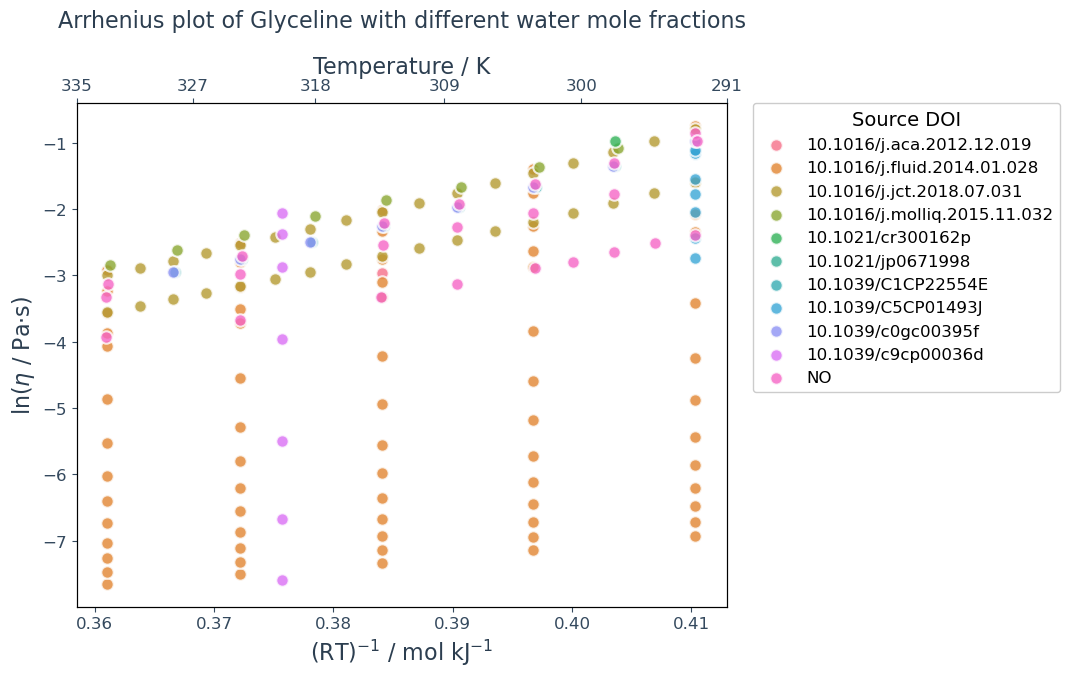

All linear fit activation energies by water mole fraction and source DOI, including ordinate and statistic:


,water_mole_fraction,activation_energy,source_doi,ordinate,statistic,color
0,0.000,43.992360,NO,-19.071649,0.998664,#f566c6
1,0.000,43.647835,10.1039/C1CP22554E,-18.998364,0.999017,#36abb2
2,0.000,41.128327,10.1016/j.molliq.2015.11.032,-17.701857,0.999505,#8aa631
3,0.000,44.548167,10.1016/j.jct.2018.07.031,-19.123307,0.999280,#b59a31
4,0.000,44.401167,10.1016/j.fluid.2014.01.028,-19.007296,0.998474,#e18531
5,0.000,45.099537,10.1039/c0gc00395f,-19.540212,0.998521,#8e92f4
6,0.108,42.740921,10.1016/j.fluid.2014.01.028,-18.699900,0.999226,#e18531
7,0.156,45.115184,NO,-19.780154,0.963541,#f566c6
8,0.238,39.488831,10.1016/j.fluid.2014.01.028,-17.869946,0.997722,#e18531
9,0.254,39.548897,10.1016/j.jct.2018.07.031,-17.874516,0.999111,#b59a31


Saved activation energy data to 'df_data_glyceline_ratio_or_pure_water.csv'


In [46]:
df_data_glyceline_ratio_or_pure_water_filtered = df_data_glyceline_ratio_or_pure_water_filtered[
    (df_data_glyceline_ratio_or_pure_water_filtered['temperature'] > 293) &
    (df_data_glyceline_ratio_or_pure_water_filtered['temperature'] < 335)
]

# Clean for missing values in variables used
plot_df = df_data_glyceline_ratio_or_pure_water_filtered[
    df_data_glyceline_ratio_or_pure_water_filtered["viscosity_value"].notnull() &
    df_data_glyceline_ratio_or_pure_water_filtered["temperature"].notnull() &
    df_data_glyceline_ratio_or_pure_water_filtered["source_doi"].notnull()
].copy()

# Calculate ln(viscosity) and 1/(R*T)
R = 8.314  # J/(mol*K)
plot_df["inv_RT"] = 1000 / (R * plot_df["temperature"].astype(float))  # Factor 1000 for kJ instead of J
plot_df["ln_viscosity"] = np.log(plot_df["viscosity_value"].astype(float))

# Use mole_fraction_water to color the water amount
plot_df["water_mole_fraction"] = plot_df["mole_fraction_water"].astype(float)

# We'll use unique discrete values for source_doi as hue
unique_dois = np.sort(plot_df["source_doi"].unique())

# Set up beautiful colormap: use a curated set of distinct, pleasant colors
N = len(unique_dois)
# Curated beautiful color palette with distinct, pleasant colors
beautiful_colors = [
    '#ffba08',  # Amber Flame
    '#3185fc',  # Azure Blue
    '#8fe388',  # Light Green
    '#d00000',  # Brick Ember
    '#cbff8c',  # Lime Cream
    '#1b998b',  # Verdigris
    '#5d2e8c',  # Rebecca Purple
    '#46237a',  # Indigo Velvet
    '#ff7b9c',  # Petal Rouge
    '#ff9b85',  # Salmon
]

if N <= len(beautiful_colors):
    color_dict = {doi: beautiful_colors[i] for i, doi in enumerate(unique_dois)}
else:
    # Fall back to seaborn color palette for many DOIs
    colors = sns.color_palette("husl", N)
    # Convert RGB tuples to hex strings
    color_dict = {doi: '#{:02x}{:02x}{:02x}'.format(int(colors[i][0]*255), int(colors[i][1]*255), int(colors[i][2]*255)) for i, doi in enumerate(unique_dois)}

plt.figure(figsize=(11,7))
ax = plt.gca()

# Increase font size globally
plt.rcParams.update({'font.size': 14})

# Scatter points for each discrete DOI, so legend can be discrete
for i, doi in enumerate(unique_dois):
    subset = plot_df[plot_df["source_doi"] == doi]
    ax.scatter(
        subset["inv_RT"], 
        subset["ln_viscosity"], 
        color=color_dict[doi],
        s=80, 
        edgecolor='white',
        linewidth=1.5,
        alpha=0.8,
        label=f"{doi}"
    )

# Linear fit and store slopes per discrete water content, including source_doi
slope_results = []
# Round water mole fraction for grouping
plot_df["water_mole_fraction_rounded"] = plot_df["water_mole_fraction"].round(3)
discrete_mole_fractions = np.sort(plot_df["water_mole_fraction_rounded"].unique())

for mf in discrete_mole_fractions:
    group = plot_df[plot_df["water_mole_fraction_rounded"] == mf]
    # For each unique source_doi in this water content, do a fit for that subset
    for doi in group["source_doi"].unique():
        doi_group = group[group["source_doi"] == doi]
        if len(doi_group) >= 2:
            x = doi_group["inv_RT"].values
            y = doi_group["ln_viscosity"].values
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            xfit = np.linspace(x.min(), x.max(), 50)
            yfit = intercept + slope * xfit
            # Optionally: plot fits per color, commented
            # ax.plot(xfit, yfit, linestyle='--', linewidth=2, color=color_dict[doi])
            mf_tuple = (tuple(doi_group["mole_fractions"].iloc[0]) if "mole_fractions" in doi_group.columns and isinstance(doi_group["mole_fractions"].iloc[0], (list, tuple)) 
                        else doi_group["mole_fractions"].iloc[0] if "mole_fractions" in doi_group.columns else None)
            slope_results.append({
                "mole_fractions": mf_tuple,
                "water_mole_fraction": float(mf),
                "slope": slope,
                "source_doi": doi,
                "ordinate": intercept,
                "statistic": r_value,
                "color": color_dict[doi]
            })

# Create secondary x-axis for temperature
ax2 = ax.twiny()

# Get the range of 1/(R*T) values to create corresponding temperature values
inv_RT_min, inv_RT_max = ax.get_xlim()
T_max = 1000 / (R * inv_RT_min)  # Higher temperature corresponds to lower 1/(R*T), factor 1000 for kJ
T_min = 1000 / (R * inv_RT_max)  # Lower temperature corresponds to higher 1/(R*T), factor 1000 for kJ

# Set temperature ticks
temp_ticks = np.linspace(T_min, T_max, 6)  # 6 temperature points
inv_RT_ticks = 1000 / (R * temp_ticks)  # Factor 1000 for kJ

ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(inv_RT_ticks)
ax2.set_xticklabels([f'{T:.0f}' for T in temp_ticks])
ax2.set_xlabel('Temperature / K', fontsize=16, color='#2C3E50')

# Make discrete legend without shadow
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
lgd = ax.legend(by_label.values(), by_label.keys(), title="Source DOI", 
               bbox_to_anchor=(1.04, 1), loc='upper left', borderaxespad=0., 
               fontsize=12, frameon=True, fancybox=True, shadow=False)
lgd.get_title().set_fontsize(14)
lgd.get_frame().set_facecolor('white')
lgd.get_frame().set_alpha(1.0)

plt.title('Arrhenius plot of Glyceline with different water mole fractions', 
          fontsize=16, color='#2C3E50', pad=20)
ax.set_xlabel('(RT)$^{-1}$ / mol kJ$^{-1}$', fontsize=16, color='#2C3E50')
ax.set_ylabel('ln($\eta$ / Pa$\cdot$s)', fontsize=16, color='#2C3E50')
ax.tick_params(axis='both', which='major', labelsize=12, colors='#34495E')
ax2.tick_params(axis='x', which='major', labelsize=12, colors='#34495E')

# Set white background color
ax.set_facecolor('white')
plt.tight_layout()
save_plot_as_svg()
plt.show()

import pandas as pd
activation_energy_df = pd.DataFrame(slope_results)
# Rename for clarity
activation_energy_df_og = activation_energy_df.rename(columns={'slope': 'activation_energy'})
# Ensure 'ordinate' and 'statistic' columns are present (they are, see above)
print("All linear fit activation energies by water mole fraction and source DOI, including ordinate and statistic:")
display(activation_energy_df_og[["water_mole_fraction", "activation_energy", "source_doi", "ordinate", "statistic", "color"]])

activation_energy_df_og['measurement'] = 'measured'
activation_energy_df_og.to_csv('activation_energy_results_measured.csv', index=False)


# Add a column called 'measured' and fill it with 'measured'
df_data_glyceline_ratio_or_pure_water_filtered['measured'] = 'measured'

# Save the activation energy data to CSV
df_data_glyceline_ratio_or_pure_water_filtered.to_csv('df_data_glyceline_ratio_or_pure_water.csv', index=False)
print("Saved activation energy data to 'df_data_glyceline_ratio_or_pure_water.csv'")

✓ Plot gespeichert: image_output/plot_25.svg (49,620 Bytes)


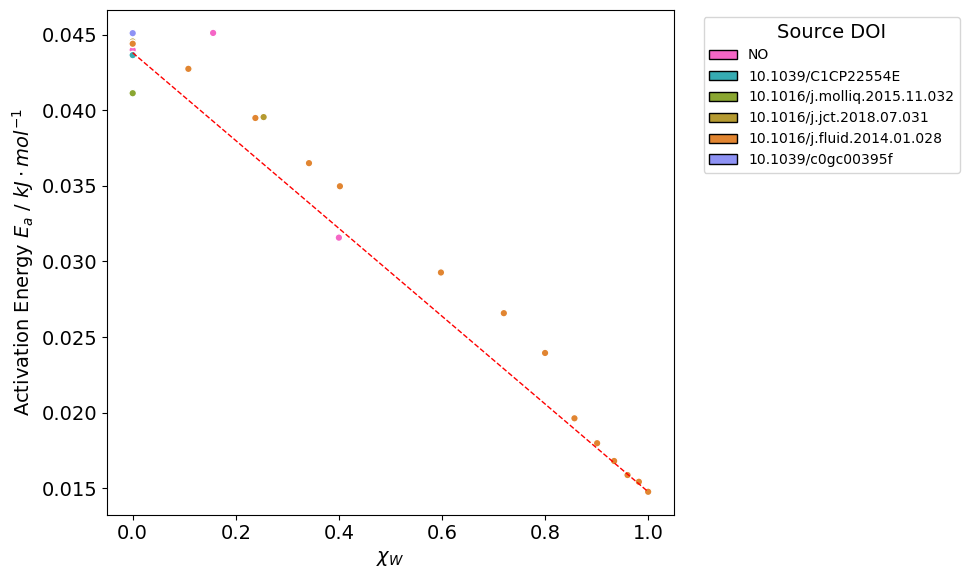

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Use the color column directly
colors = activation_energy_df_og['color']

# Convert activation energy from J/mol to kJ/mol
activation_energy_kJ = activation_energy_df_og['activation_energy'] / 1000

scatter = plt.scatter(
    activation_energy_df_og['water_mole_fraction'],
    activation_energy_kJ,
    c=colors,
    s=30,
    edgecolor='w'
)

# Calculate mean activation energy for 0 and 1 water fraction (in kJ/mol)
mean_0_water = activation_energy_df_og[activation_energy_df_og['water_mole_fraction'] == 0.0]['activation_energy'].mean() / 1000
mean_1_water = activation_energy_df_og[activation_energy_df_og['water_mole_fraction'] == 1.0]['activation_energy'].mean() / 1000

# Add red line between the means
plt.plot([0.0, 1.0], [mean_0_water, mean_1_water], 'r--', linewidth=1, label='Mean trend')

# Make a discrete legend per source_doi using the color column
unique_dois = activation_energy_df_og['source_doi'].unique()
from matplotlib.patches import Patch
legend_handles = []
for doi in unique_dois:
    # Get the color for this DOI from the first occurrence
    color = activation_energy_df_og[activation_energy_df_og['source_doi'] == doi]['color'].iloc[0]
    legend_handles.append(Patch(facecolor=color, edgecolor='k', label=f"{doi}"))

plt.legend(handles=legend_handles, title="Source DOI", bbox_to_anchor=(1.04, 1), loc='upper left', fontsize=10)

plt.xlabel(r'$\chi_W$')
plt.ylabel(r'Activation Energy $E_a$ / $kJ \cdot mol^{-1}$')
plt.tight_layout()
save_plot_as_svg()
plt.show()


In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Use the color column directly
colors = activation_energy_df['color']

# Convert activation energy from J/mol to kJ/mol
activation_energy_kJ = activation_energy_df['activation_energy'] / 1000

scatter = plt.scatter(
    activation_energy_df['water_mole_fraction'],
    activation_energy_kJ,
    c=colors,
    s=80,
    edgecolor='w'
)

# Calculate mean activation energy for 0 and 1 water fraction (in kJ/mol)
mean_0_water = activation_energy_df[activation_energy_df['water_mole_fraction'] == 0.0]['activation_energy'].mean() / 1000
mean_1_water = activation_energy_df[activation_energy_df['water_mole_fraction'] == 1.0]['activation_energy'].mean() / 1000

# Add red line between the means
plt.plot([0.0, 1.0], [mean_0_water, mean_1_water], 'r--', linewidth=1, label='Mean trend')

# Make a discrete legend per source_doi using the color column
unique_dois = activation_energy_df['source_doi'].unique()
from matplotlib.patches import Patch
legend_handles = []
for doi in unique_dois:
    # Get the color for this DOI from the first occurrence
    color = activation_energy_df[activation_energy_df['source_doi'] == doi]['color'].iloc[0]
    legend_handles.append(Patch(facecolor=color, edgecolor='k', label=f"{doi}"))

plt.legend(handles=legend_handles, title="Source DOI", bbox_to_anchor=(1.04, 1), loc='upper left', fontsize=10)

plt.xlabel('$\chi_W$')
plt.ylabel('Activation Energy $E_a$ / $kJ \cdot mol^{-1}$')
plt.tight_layout()
save_plot_as_svg()
plt.show()


<>:37: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\c'
<>:37: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_13941/1355864785.py:37: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('$\chi_W$')
/tmp/ipykernel_13941/1355864785.py:38: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('Activation Energy $E_a$ / $kJ \cdot mol^{-1}$')
/tmp/ipykernel_13941/1355864785.py:37: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('$\chi_W$')
/tmp/ipykernel_13941/1355864785.py:38: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('Activation Energy $E_a$ / $kJ \cdot mol^{-1}$')


KeyError: 'activation_energy'

<Figure size 1000x600 with 0 Axes>

<>:68: SyntaxWarning: invalid escape sequence '\c'
<>:72: SyntaxWarning: invalid escape sequence '\c'
<>:73: SyntaxWarning: invalid escape sequence '\D'
<>:68: SyntaxWarning: invalid escape sequence '\c'
<>:72: SyntaxWarning: invalid escape sequence '\c'
<>:73: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_17091/2251435907.py:68: SyntaxWarning: invalid escape sequence '\c'
  legend_handles.append(Patch(facecolor='black', edgecolor='k', label='Mean of Activation Energy at $\chi_W = 0$'))
/tmp/ipykernel_17091/2251435907.py:72: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('$\chi_W$')
/tmp/ipykernel_17091/2251435907.py:73: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$\Delta E_a^{excess}$ / $kJ \cdot mol^{-1}$')


✓ Plot gespeichert: image_output/plot_11.svg (54,384 Bytes)


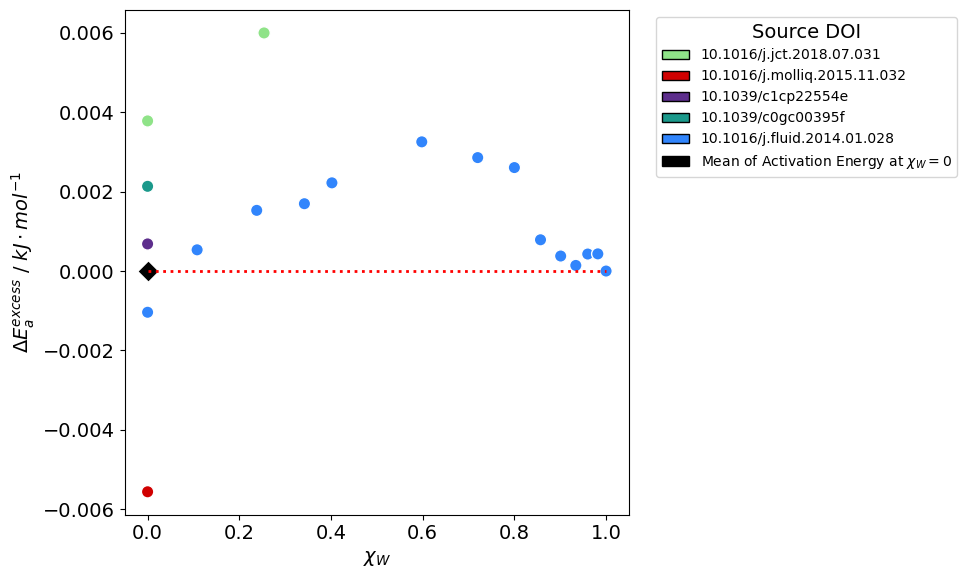

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Separate data for water_mole_fraction == 0 and others
zero_water_data = activation_energy_df[activation_energy_df['water_mole_fraction'] == 0.0]
other_data = activation_energy_df[activation_energy_df['water_mole_fraction'] != 0.0]

# Calculate mean activation energy for zero water content (in kJ/mol)
mean_0_water = zero_water_data['activation_energy'].mean() / 1000
mean_1_water = activation_energy_df[activation_energy_df['water_mole_fraction'] == 1.0]['activation_energy'].mean() / 1000

# Calculate the linear trend line values for each data point
water_fractions = activation_energy_df['water_mole_fraction']
trend_line_values = mean_0_water + (mean_1_water - mean_0_water) * water_fractions

# Calculate residues for all data points
activation_energy_kJ = activation_energy_df['activation_energy'] / 1000
residues = activation_energy_kJ - trend_line_values

# Plot zero water content points individually
zero_water_residues = residues[activation_energy_df['water_mole_fraction'] == 0.0]
plt.scatter(
    zero_water_data['water_mole_fraction'],
    zero_water_residues,
    c=zero_water_data['color'],
    s=80,
    edgecolor='w'
)

# For zero water content, also calculate residue for the mean point
zero_water_residue = mean_0_water - mean_0_water  # This will be 0

# Plot the mean point for zero water content
plt.scatter(
    0.0,
    zero_water_residue,
    c='black',
    s=120,
    edgecolor='w',
    marker='D',
    label='Mean (0% water)'
)

# Plot other data points colored by DOI
scatter = plt.scatter(
    other_data['water_mole_fraction'],
    residues[activation_energy_df['water_mole_fraction'] != 0.0],
    c=other_data['color'],
    s=80,
    edgecolor='w'
)

# Add dotted red line connecting mean at mole fraction 0 to mole fraction 1
one_water_residue = mean_1_water - (mean_0_water + (mean_1_water - mean_0_water) * 1.0)
plt.plot([0.0, 1.0], [zero_water_residue, one_water_residue], 'r:', linewidth=2, label='Mean trend')

# Make a discrete legend per source_doi using the color column
unique_dois = activation_energy_df['source_doi'].unique()
from matplotlib.patches import Patch
legend_handles = []
for doi in unique_dois:
    # Get the color for this DOI from the first occurrence
    color = activation_energy_df[activation_energy_df['source_doi'] == doi]['color'].iloc[0]
    legend_handles.append(Patch(facecolor=color, edgecolor='k', label=f"{doi}"))

legend_handles.append(Patch(facecolor='black', edgecolor='k', label='Mean of Activation Energy at $\chi_W = 0$'))

plt.legend(handles=legend_handles, title="Source DOI", bbox_to_anchor=(1.04, 1), loc='upper left', fontsize=10)

plt.xlabel('$\chi_W$')
plt.ylabel('$\Delta E_a^{excess}$ / $kJ \cdot mol^{-1}$')
plt.tight_layout()
save_plot_as_svg()
plt.show()


<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_17091/3236673562.py:30: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('Activation Energy $E_a$ / $kJ \cdot mol^{-1}$')


✓ Plot gespeichert: image_output/plot_12.svg (48,582 Bytes)


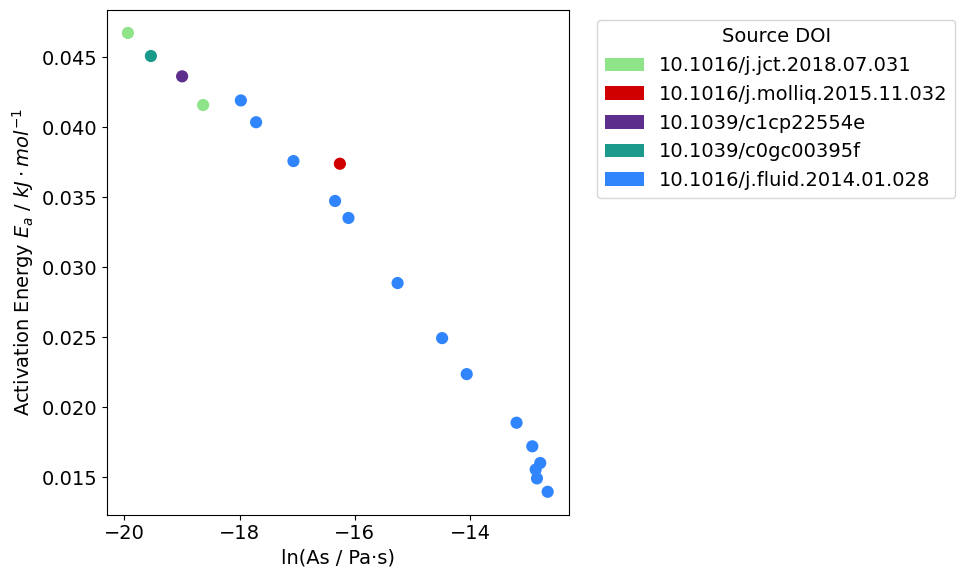

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Use the color column directly
colors = activation_energy_df['color']

# Convert activation energy from J/mol to kJ/mol
activation_energy_kJ = activation_energy_df['activation_energy'] / 1000

scatter = plt.scatter(
    activation_energy_df['ordinate'],
    activation_energy_kJ,
    c=colors,
    s=60
)

# Make a discrete legend per source_doi using the color column
unique_dois = activation_energy_df['source_doi'].unique()
from matplotlib.patches import Patch
legend_handles = []
for doi in unique_dois:
    # Get the color for this DOI from the first occurrence
    color = activation_energy_df[activation_energy_df['source_doi'] == doi]['color'].iloc[0]
    legend_handles.append(Patch(facecolor=color, label=f"{doi}"))

plt.legend(handles=legend_handles, title="Source DOI", bbox_to_anchor=(1.04, 1), loc='upper left')

plt.xlabel('ln(As / Pa·s)')
plt.ylabel('Activation Energy $E_a$ / $kJ \cdot mol^{-1}$')

plt.tight_layout()
save_plot_as_svg()
plt.show()


In [ ]:
activation_energy_df_combined = pd.concat([activation_energy_df, activation_energies_pure], ignore_index=True)
if 'mole_fractions' in activation_energy_df_combined.columns:
    activation_energy_df_combined = activation_energy_df_combined.drop(columns=['mole_fractions'])
activation_energy_df_combined['molar_ratio'] = activation_energy_df_combined['molar_ratio'].fillna(2)
activation_energy_df_combined

,water_mole_fraction,activation_energy,source_doi,ordinate,statistic,color,measurement,molar_ratio
0,0.000,46.748109,10.1016/j.jct.2018.07.031,-19.938777,0.998271,#8fe388,measured,2.0
1,0.000,37.401011,10.1016/j.molliq.2015.11.032,-16.260954,0.996212,#d00000,measured,2.0
2,0.000,43.647835,10.1039/c1cp22554e,-18.998364,0.999017,#5d2e8c,measured,2.0
3,0.000,45.099537,10.1039/c0gc00395f,-19.540212,0.998521,#1b998b,measured,2.0
4,0.000,41.925535,10.1016/j.fluid.2014.01.028,-17.979190,0.996304,#3185fc,measured,2.0
5,0.108,40.366403,10.1016/j.fluid.2014.01.028,-17.714444,0.996411,#3185fc,measured,2.0
6,0.238,37.590289,10.1016/j.fluid.2014.01.028,-17.066439,0.995796,#3185fc,measured,2.0
7,0.254,41.597359,10.1016/j.jct.2018.07.031,-18.633964,0.998101,#8fe388,measured,2.0
8,0.342,34.740694,10.1016/j.fluid.2014.01.028,-16.344019,0.996203,#3185fc,measured,2.0
9,0.402,33.526415,10.1016/j.fluid.2014.01.028,-16.112062,0.996679,#3185fc,measured,2.0


In [ ]:
# Apply the activation energy calculation logic from Cell 11 (lines 1-97) 
# to the data from Cell 15/16 (lines 1-186)
# This splits the data by temperature groups and calculates activation energies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the plot_df from Cell 15/16 (or recreate it if needed)
# Make sure we have the filtered data with inv_RT and ln_viscosity calculated
if 'plot_df' not in locals() and 'plot_df' not in globals():
    # Recreate plot_df from df_data_glyceline_ratio_or_pure_water_filtered if it exists
    if 'df_data_glyceline_ratio_or_pure_water_filtered' in locals() or 'df_data_glyceline_ratio_or_pure_water_filtered' in globals():
        plot_df = df_data_glyceline_ratio_or_pure_water_filtered[
            df_data_glyceline_ratio_or_pure_water_filtered["viscosity_value"].notnull() &
            df_data_glyceline_ratio_or_pure_water_filtered["temperature"].notnull() &
            df_data_glyceline_ratio_or_pure_water_filtered["source_doi"].notnull()
        ].copy()
        
        R = 8.314  # J/(mol*K)
        plot_df["inv_RT"] = 1 / (R * plot_df["temperature"].astype(float))
        plot_df["ln_viscosity"] = np.log(plot_df["viscosity_value"].astype(float)/1000)
    else:
        raise ValueError("plot_df or df_data_glyceline_ratio_or_pure_water_filtered not found. Please run Cell 15/16 first.")

# Create a composition identifier from mole_fractions for grouping
# Convert mole_fractions to tuple for grouping (if it's a list/tuple)
def get_composition_key(mf):
    """Convert mole_fractions to a hashable tuple for grouping."""
    if isinstance(mf, (list, tuple)):
        # Round to 3 decimal places for grouping similar compositions
        return tuple(round(x, 3) for x in mf)
    elif pd.isna(mf):
        return None
    else:
        return (round(float(mf), 3),)

plot_df = plot_df.copy()
plot_df['composition_key'] = plot_df['mole_fractions'].apply(get_composition_key)

# Get unique combinations of DOI and composition
doi_composition_combinations = plot_df[
    plot_df['composition_key'].notna() &
    plot_df['source_doi'].notna() &
    (~plot_df["inv_RT"].isna()) &
    (~plot_df["ln_viscosity"].isna())
][['source_doi', 'composition_key']].drop_duplicates()

# List to store all split data
split_data = []

# Process each valid DOI-composition combination - split into temperature groups (High T and Low T)
for _, row in doi_composition_combinations.iterrows():
    doi = row['source_doi']
    comp_key = row['composition_key']
    
    subset = plot_df[
        (plot_df["source_doi"] == doi) &
        (plot_df["composition_key"] == comp_key) &
        (~plot_df["inv_RT"].isna()) &
        (~plot_df["ln_viscosity"].isna())
    ]
    
    if len(subset) < 2:
        continue  # Not enough points to split
    
    # Sort by temperature (inverse of inv_RT for proper ordering)
    subset_sorted = subset.sort_values('inv_RT')
    
    # Split into two halves based on temperature
    n_points = len(subset_sorted)
    mid_point = n_points // 2
    
    # Lower half (higher temperatures - lower inv_RT values)
    low_temp_group = subset_sorted.iloc[:mid_point].copy()
    low_temp_group['temperature_group'] = 'High T'
    
    # Upper half (lower temperatures - higher inv_RT values)  
    high_temp_group = subset_sorted.iloc[mid_point:].copy()
    high_temp_group['temperature_group'] = 'Low T'
    
    # Add to split_data list
    split_data.append(low_temp_group)
    split_data.append(high_temp_group)

# Combine all split data into a single DataFrame
split_points_df = pd.concat(split_data, ignore_index=True)

print(f"Split points DataFrame shape: {split_points_df.shape}")
print("\nTemperature group distribution:")
print(split_points_df['temperature_group'].value_counts())
display(split_points_df.head(10))

# Now apply the activation energy calculation logic from Cell 11
R = 8.314462618  # J/mol/K (universal gas constant)

group_activation_energies = []

# Get unique combinations of DOI, composition, and temperature group
doi_comp_temp_combinations = split_points_df[['source_doi', 'composition_key', 'temperature_group']].drop_duplicates()

for _, row in doi_comp_temp_combinations.iterrows():
    doi = row['source_doi']
    comp_key = row['composition_key']
    temp_group = row['temperature_group']
    
    subset = split_points_df[
        (split_points_df['source_doi'] == doi) & 
        (split_points_df['composition_key'] == comp_key) &
        (split_points_df['temperature_group'] == temp_group)
    ]
    
    if len(subset) < 2:
        continue  # Not enough points to fit
    
    # Calculate temperature range for this subset
    temp_min = subset['temperature'].min()
    temp_max = subset['temperature'].max()
    temp_range = f"{temp_min:.0f}-{temp_max:.0f}"
    
    # Fit: ln(viscosity) = slope * inv_RT + intercept
    x = subset["inv_RT"].values
    y = subset["ln_viscosity"].values
    
    # np.polyfit returns [slope, intercept]
    slope, intercept = np.polyfit(x, y, 1)
    E_a = slope * R  # activation energy in J/mol
    
    # Calculate R-squared for goodness of fit
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    
    group_activation_energies.append({
        "source_doi": doi,
        "composition_key": comp_key,
        "temperature_group": temp_group,
        "temperature_range": temp_range,
        "activation_energy_J_per_mol": E_a,
        "arrhenius_prefactor_lnA": intercept,
        "r_squared": r_squared,
        "n_points": len(subset)
    })

# Also calculate activation energy for full temperature range for each DOI-composition combination
doi_comp_combinations = split_points_df[['source_doi', 'composition_key']].drop_duplicates()

for _, row in doi_comp_combinations.iterrows():
    doi = row['source_doi']
    comp_key = row['composition_key']
    subset = split_points_df[
        (split_points_df['source_doi'] == doi) &
        (split_points_df['composition_key'] == comp_key)
    ]
    
    if len(subset) < 2:
        continue  # Not enough points to fit
    
    # Calculate temperature range for this subset
    temp_min = subset['temperature'].min()
    temp_max = subset['temperature'].max()
    temp_range = f"{temp_min:.0f}-{temp_max:.0f}"
    
    # Fit: ln(viscosity) = slope * inv_RT + intercept
    x = subset["inv_RT"].values
    y = subset["ln_viscosity"].values
    
    # np.polyfit returns [slope, intercept]
    slope, intercept = np.polyfit(x, y, 1)
    E_a = slope * R  # activation energy in J/mol
    
    # Calculate R-squared for goodness of fit
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    
    group_activation_energies.append({
        "source_doi": doi,
        "composition_key": comp_key,
        "temperature_group": "Full Range",
        "temperature_range": temp_range,
        "activation_energy_J_per_mol": E_a,
        "arrhenius_prefactor_lnA": intercept,
        "r_squared": r_squared,
        "n_points": len(subset)
    })

# Convert to DataFrame for summary display
group_activation_energy_df = pd.DataFrame(group_activation_energies)

print("\nActivation energies (E_a) and Arrhenius prefactor by DOI and temperature group:")
display(group_activation_energy_df)

Split points DataFrame shape: (203, 26)

Temperature group distribution:
temperature_group
Low T     110
High T     93
Name: count, dtype: int64


,fluid_compounds,property_type,property_value,uncertainty,temperature,mole_fractions,measurement_id,source_doi,Mole fraction,Temperature,...,composition_temp_id,viscosity_value,viscosity_uncertainty,mole_fraction_water,inv_RT,ln_viscosity,water_mole_fraction,water_mole_fraction_rounded,composition_key,temperature_group
0,[Water],viscosity,0.000331,0.000002,363.15,[1.0],57752fcf-7087-418f-8443-180470bce062,10.1016/j.fluid.2014.01.028,1.0000,363.15,...,"((Water,), 363.15, 57752fcf-7087-418f-8443-180...",0.000331,0.000002,1.0000,0.331210,-8.014601,1.0000,1.000,"(1.0,)",High T
1,[Water],viscosity,0.000386,0.000002,353.15,[1.0],a391af92-cf16-4076-bd90-c835c63511b9,10.1016/j.fluid.2014.01.028,1.0000,353.15,...,"((Water,), 353.15, a391af92-cf16-4076-bd90-c83...",0.000386,0.000002,1.0000,0.340589,-7.859673,1.0000,1.000,"(1.0,)",High T
2,[Water],viscosity,0.000435,0.000002,343.15,[1.0],dc548f08-57ea-4102-b45c-647ea283ef16,10.1016/j.fluid.2014.01.028,1.0000,343.15,...,"((Water,), 343.15, dc548f08-57ea-4102-b45c-647...",0.000435,0.000002,1.0000,0.350514,-7.739245,1.0000,1.000,"(1.0,)",High T
3,[Water],viscosity,0.000477,0.000002,333.15,[1.0],2dba9cd5-5ff5-4384-a5a7-eeea3df8b136,10.1016/j.fluid.2014.01.028,1.0000,333.15,...,"((Water,), 333.15, 2dba9cd5-5ff5-4384-a5a7-eee...",0.000477,0.000002,1.0000,0.361036,-7.647994,1.0000,1.000,"(1.0,)",High T
4,[Water],viscosity,0.000549,0.000003,323.15,[1.0],a320de01-0c91-4124-ba7d-5480fb9964fa,10.1016/j.fluid.2014.01.028,1.0000,323.15,...,"((Water,), 323.15, a320de01-0c91-4124-ba7d-548...",0.000549,0.000003,1.0000,0.372208,-7.507959,1.0000,1.000,"(1.0,)",Low T
5,[Water],viscosity,0.000649,0.000003,313.15,[1.0],3ee182dd-7f4d-4242-b066-602461767760,10.1016/j.fluid.2014.01.028,1.0000,313.15,...,"((Water,), 313.15, 3ee182dd-7f4d-4242-b066-602...",0.000649,0.000003,1.0000,0.384094,-7.339770,1.0000,1.000,"(1.0,)",Low T
6,[Water],viscosity,0.000791,0.000004,303.15,[1.0],a73fc0a6-3c04-4d27-b837-fda3899ab3f9,10.1016/j.fluid.2014.01.028,1.0000,303.15,...,"((Water,), 303.15, a73fc0a6-3c04-4d27-b837-fda...",0.000791,0.000004,1.0000,0.396764,-7.141707,1.0000,1.000,"(1.0,)",Low T
7,[Water],viscosity,0.000984,0.000005,293.15,[1.0],7bdb635e-bc87-4a76-aff9-ed2266d7ecd3,10.1016/j.fluid.2014.01.028,1.0000,293.15,...,"((Water,), 293.15, 7bdb635e-bc87-4a76-aff9-ed2...",0.000984,0.000005,1.0000,0.410299,-6.924291,1.0000,1.000,"(1.0,)",Low T
8,[Water],viscosity,0.001274,0.000006,283.15,[1.0],47179c39-a8ad-446e-a401-6bd775b8f5ca,10.1016/j.fluid.2014.01.028,1.0000,283.15,...,"((Water,), 283.15, 47179c39-a8ad-446e-a401-6bd...",0.001274,0.000006,1.0000,0.424789,-6.665672,1.0000,1.000,"(1.0,)",Low T
9,"[Choline Chloride, Glycerol, Water]",viscosity,0.000386,0.000002,363.15,"[0.006033333333, 0.012066666667, 0.9819]",c7a0830a-12f8-42b6-8e40-e19325f0a9c9,10.1016/j.fluid.2014.01.028,0.9819,363.15,...,"((Choline Chloride, Glycerol, Water), 363.15, ...",0.000386,0.000002,0.9819,0.331210,-7.859155,0.9819,0.982,"(0.006, 0.012, 0.982)",High T



Activation energies (E_a) and Arrhenius prefactor by DOI and temperature group:


,source_doi,composition_key,temperature_group,temperature_range,activation_energy_J_per_mol,arrhenius_prefactor_lnA,r_squared,n_points
0,10.1016/j.fluid.2014.01.028,"(1.0,)",High T,333-363,101.695137,-12.045355,0.979997,4
1,10.1016/j.fluid.2014.01.028,"(1.0,)",Low T,283-323,133.132418,-13.482804,0.998242,5
2,10.1016/j.fluid.2014.01.028,"(0.006, 0.012, 0.982)",High T,333-363,105.119756,-12.048167,0.998417,4
3,10.1016/j.fluid.2014.01.028,"(0.006, 0.012, 0.982)",Low T,283-323,137.545277,-13.496073,0.998425,5
4,10.1016/j.fluid.2014.01.028,"(0.013, 0.027, 0.96)",High T,333-363,114.367397,-12.235612,0.998282,4
5,10.1016/j.fluid.2014.01.028,"(0.013, 0.027, 0.96)",Low T,283-323,142.224808,-13.490797,0.998025,5
6,10.1016/j.fluid.2014.01.028,"(0.022, 0.044, 0.933)",High T,333-363,99.792999,-11.389993,0.970668,4
7,10.1016/j.fluid.2014.01.028,"(0.022, 0.044, 0.933)",Low T,283-323,149.777368,-13.585480,0.998321,5
8,10.1016/j.fluid.2014.01.028,"(0.033, 0.066, 0.901)",High T,333-363,118.438775,-11.887904,0.998875,4
9,10.1016/j.fluid.2014.01.028,"(0.033, 0.066, 0.901)",Low T,283-323,159.518940,-13.716042,0.998529,5


✓ Plot gespeichert: image_output/plot_14.svg (65,899 Bytes)


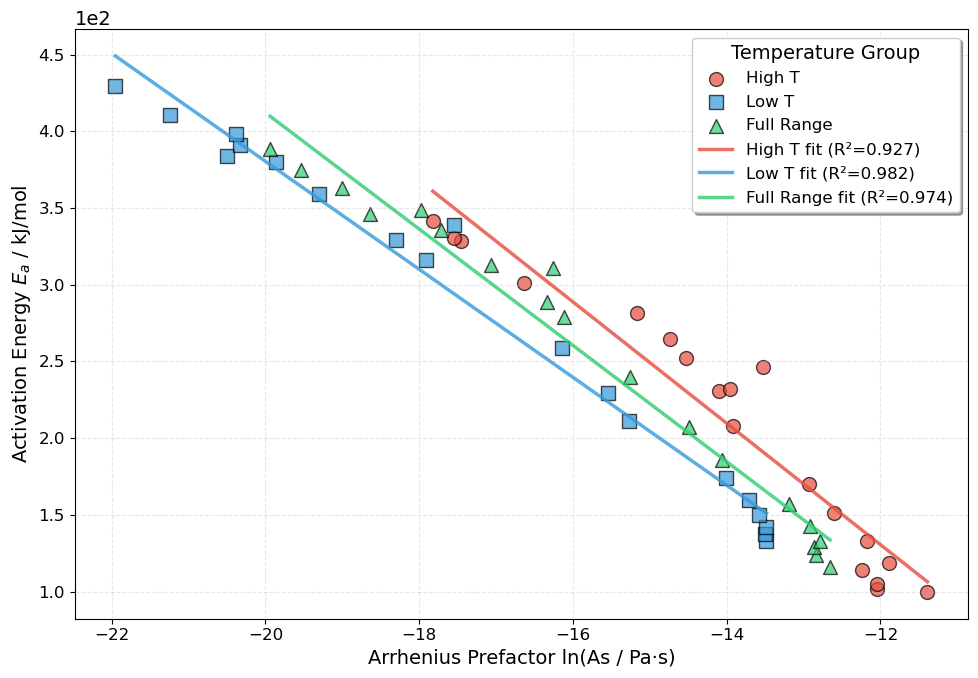


Summary Statistics by Temperature Group:

High T:
  Number of data points: 19
  Activation Energy - Mean: 2.11e+02 J/mol
  Activation Energy - Std: 8.49e+01 J/mol
  Arrhenius Prefactor - Mean: -14.04
  Arrhenius Prefactor - Std: 2.07
  Regression - Slope: -3.96e+01
  Regression - Intercept: -344.19
  Regression - R²: 0.9270
  Regression - P-value: 4.3067e-11
  Regression - Std error: 2.69e+00

Low T:
  Number of data points: 19
  Activation Energy - Mean: 2.81e+02 J/mol
  Activation Energy - Std: 1.08e+02 J/mol
  Arrhenius Prefactor - Mean: -17.16
  Arrhenius Prefactor - Std: 3.05
  Regression - Slope: -3.52e+01
  Regression - Intercept: -323.30
  Regression - R²: 0.9817
  Regression - P-value: 3.3054e-16
  Regression - Std error: 1.17e+00

Full Range:
  Number of data points: 19
  Activation Energy - Mean: 2.52e+02 J/mol
  Activation Energy - Std: 9.77e+01 J/mol
  Arrhenius Prefactor - Mean: -15.77
  Arrhenius Prefactor - Std: 2.54
  Regression - Slope: -3.79e+01
  Regression - Inter

In [ ]:
# Plot activation_energy_J_per_mol vs arrhenius_prefactor_lnA from group_activation_energy_df
# Color by temperature group with regression lines
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Check if group_activation_energy_df exists
if 'group_activation_energy_df' not in locals() and 'group_activation_energy_df' not in globals():
    raise ValueError("group_activation_energy_df not found. Please run the previous cell first.")

# Create the plot
fig, ax = plt.subplots(figsize=(10, 7))

# Get unique temperature groups for coloring
temp_groups = group_activation_energy_df['temperature_group'].unique()
colors_map = {'High T': '#E74C3C', 'Low T': '#3498DB', 'Full Range': '#2ECC71'}
markers_map = {'High T': 'o', 'Low T': 's', 'Full Range': '^'}

# Plot each temperature group with different colors and markers
for temp_group in temp_groups:
    subset = group_activation_energy_df[group_activation_energy_df['temperature_group'] == temp_group]
    if len(subset) > 0:
        ax.scatter(
            subset['arrhenius_prefactor_lnA'],
            subset['activation_energy_J_per_mol'],
            c=colors_map.get(temp_group, '#95A5A6'),
            marker=markers_map.get(temp_group, 'o'),
            s=100,
            alpha=0.7,
            edgecolor='black',
            linewidth=1,
            label=temp_group
        )

# Add regression lines for each temperature group
for temp_group in temp_groups:
    subset = group_activation_energy_df[group_activation_energy_df['temperature_group'] == temp_group]
    
    if len(subset) >= 2:
        x = subset['arrhenius_prefactor_lnA'].values
        y = subset['activation_energy_J_per_mol'].values
        
        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        
        # Create x values for the regression line
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = slope * x_line + intercept
        
        # Plot regression line with same color as the scatter points
        ax.plot(x_line, y_line, 
               linestyle='-',
               linewidth=2.5,
               color=colors_map.get(temp_group, '#95A5A6'),
               alpha=0.8,
               label=f'{temp_group} fit (R²={r_value**2:.3f})')

# Customize the plot
ax.set_xlabel('Arrhenius Prefactor ln(As / Pa·s)', fontsize=14)
ax.set_ylabel('Activation Energy $E_a$ / kJ/mol', fontsize=14)

ax.legend(title='Temperature Group', fontsize=12, frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')

# Format y-axis to show values in scientific notation if needed
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Increase tick label font size
ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
save_plot_as_svg()
plt.show()

# Display summary statistics and regression statistics
print("\nSummary Statistics by Temperature Group:")
print("=" * 70)
for temp_group in temp_groups:
    subset = group_activation_energy_df[group_activation_energy_df['temperature_group'] == temp_group]
    if len(subset) > 0:
        print(f"\n{temp_group}:")
        print(f"  Number of data points: {len(subset)}")
        print(f"  Activation Energy - Mean: {subset['activation_energy_J_per_mol'].mean():.2e} J/mol")
        print(f"  Activation Energy - Std: {subset['activation_energy_J_per_mol'].std():.2e} J/mol")
        print(f"  Arrhenius Prefactor - Mean: {subset['arrhenius_prefactor_lnA'].mean():.2f}")
        print(f"  Arrhenius Prefactor - Std: {subset['arrhenius_prefactor_lnA'].std():.2f}")
        
        # Regression statistics
        if len(subset) >= 2:
            x = subset['arrhenius_prefactor_lnA'].values
            y = subset['activation_energy_J_per_mol'].values
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            print(f"  Regression - Slope: {slope:.2e}")
            print(f"  Regression - Intercept: {intercept:.2f}")
            print(f"  Regression - R²: {r_value**2:.4f}")
            print(f"  Regression - P-value: {p_value:.4e}")
            print(f"  Regression - Std error: {std_err:.2e}")

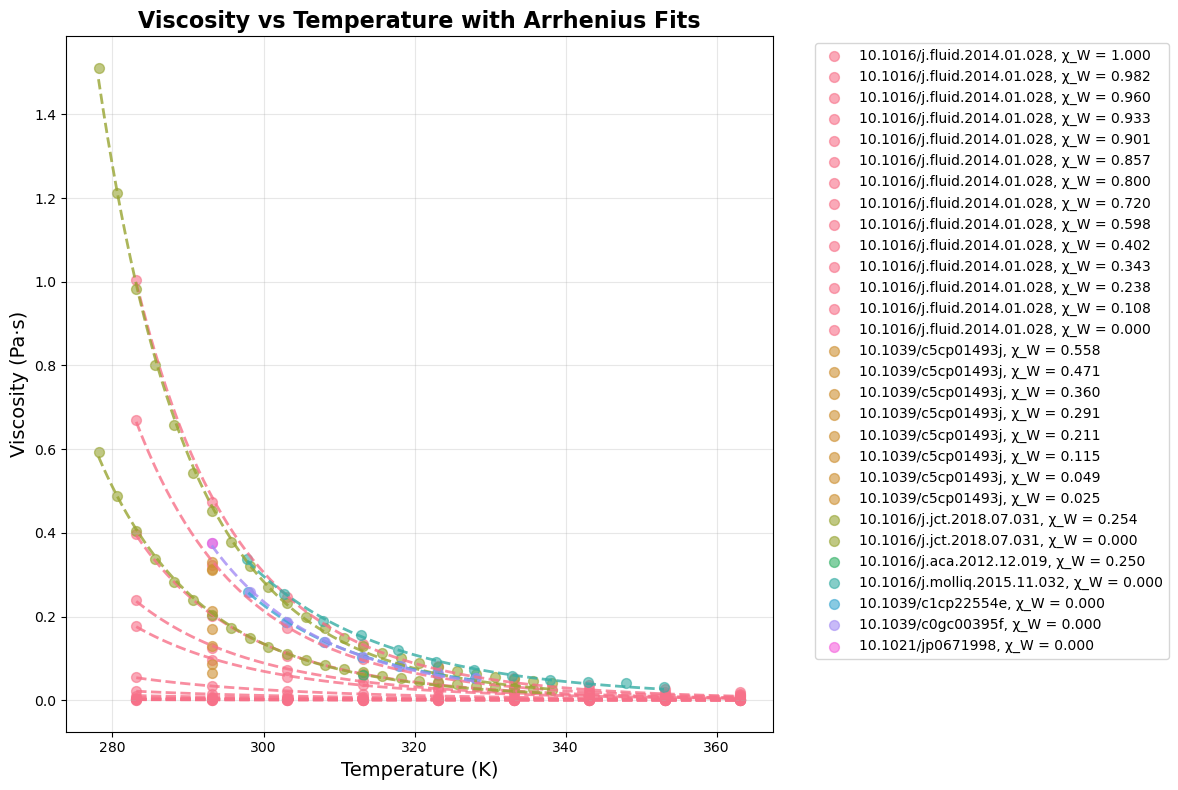

    water_mole_fraction  activation_energy                    source_doi  \
0              1.000000          14.861340   10.1016/j.fluid.2014.01.028   
1              0.981900          15.761664   10.1016/j.fluid.2014.01.028   
2              0.960200          16.400662   10.1016/j.fluid.2014.01.028   
3              0.933500          17.195939   10.1016/j.fluid.2014.01.028   
4              0.900700          18.404349   10.1016/j.fluid.2014.01.028   
5              0.857400          20.246933   10.1016/j.fluid.2014.01.028   
6              0.799700          24.370507   10.1016/j.fluid.2014.01.028   
7              0.719900          26.845289   10.1016/j.fluid.2014.01.028   
8              0.597800          31.641366   10.1016/j.fluid.2014.01.028   
9              0.402200          39.083800   10.1016/j.fluid.2014.01.028   
10             0.342500          40.926547   10.1016/j.fluid.2014.01.028   
11             0.238100          45.056889   10.1016/j.fluid.2014.01.028   
12          

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from scipy.stats import linregress
import seaborn as sns
import pandas as pd

# Set a beautiful color palette
plt.style.use('default')
sns.set_palette("husl")

# Make sure required columns exist
required_cols = [
    "viscosity_value", 
    "temperature", 
    "source_doi", 
    "mole_fraction_water",
    "Solvent: Amount ratio of component to other component of binary solvent"
]
for col in required_cols:
    if col not in df_data_glyceline_ratio_or_pure_water.columns:
        raise ValueError(f"Column '{col}' not found in dataframe.")

# Filter on solvent ratio: keep rows where ratio <=2 or ratio is NaN (missing/None)
df_data_glyceline_ratio_or_pure_water_filtered = df_data_glyceline_ratio_or_pure_water[
    (df_data_glyceline_ratio_or_pure_water["Solvent: Amount ratio of component to other component of binary solvent"].isna()) |
    (df_data_glyceline_ratio_or_pure_water["Solvent: Amount ratio of component to other component of binary solvent"] <= 2)
].copy()

# Fill missing/None values in mole_fraction_water with 0
df_data_glyceline_ratio_or_pure_water_filtered["mole_fraction_water"] = (
    df_data_glyceline_ratio_or_pure_water_filtered["mole_fraction_water"]
    .fillna(0)
    .apply(lambda x: 0 if x is None else x)
)

# Clean for missing values in variables used
plot_df = df_data_glyceline_ratio_or_pure_water_filtered[
    df_data_glyceline_ratio_or_pure_water_filtered["viscosity_value"].notnull() &
    df_data_glyceline_ratio_or_pure_water_filtered["temperature"].notnull() &
    df_data_glyceline_ratio_or_pure_water_filtered["source_doi"].notnull()
].copy()

# Create a plot of viscosity vs temperature with Arrhenius fits
fig, ax = plt.subplots(figsize=(12, 8))
# Get unique DOIs and assign colors
unique_dois = plot_df["source_doi"].unique()
colors = sns.color_palette("husl", n_colors=len(unique_dois))
doi_color_map = dict(zip(unique_dois, colors))

# Store fit results
fit_results = []

# Plot viscosity vs temperature, colored by DOI, with Arrhenius fits
for doi in unique_dois:
    doi_data = plot_df[plot_df["source_doi"] == doi].copy()
    
    # Get unique compositions within this DOI
    unique_compositions_in_doi = doi_data["mole_fraction_water"].unique()
    
    for composition in unique_compositions_in_doi:
        composition_data = doi_data[doi_data["mole_fraction_water"] == composition].copy()
        
        # Plot scatter points
        ax.scatter(composition_data["temperature"], composition_data["viscosity_value"], 
                   alpha=0.6, s=50, color=doi_color_map[doi], 
                   label=f'{doi}, χ_W = {composition:.3f}')
        
        # Fit Arrhenius equation directly: η = A * exp(Ea/(R*T))
        if len(composition_data) >= 3:  # Need at least 3 points for a meaningful fit
            T = composition_data["temperature"].values
            eta = composition_data["viscosity_value"].values
            
            # Remove any zero or negative viscosity values
            valid_mask = eta > 0
            T_valid = T[valid_mask]
            eta_valid = eta[valid_mask]
            
            if len(T_valid) >= 3:
                # Convert to numpy arrays to ensure proper type
                T_valid = np.asarray(T_valid, dtype=float)
                eta_valid = np.asarray(eta_valid, dtype=float)
                
                # Define Arrhenius function
                R = 8.314  # J/(mol·K)
                def arrhenius(T, A, Ea):
                    return A * np.exp(Ea / (R * T))
                
                # Initial guess for parameters
                # Use linearization for initial guess
                x_init = 1 / T_valid
                y_init = np.log(eta_valid)
                slope_init, intercept_init = np.polyfit(x_init, y_init, 1)
                A_init = np.exp(intercept_init)
                Ea_init = slope_init * R
                
                try:
                    # Fit the Arrhenius equation directly
                    from scipy.optimize import curve_fit
                    popt, pcov = curve_fit(arrhenius, T_valid, eta_valid, 
                                          p0=[A_init, Ea_init], maxfev=10000)
                    A_fit, Ea_fit = popt
                    
                    # Calculate R-squared
                    eta_pred = arrhenius(T_valid, A_fit, Ea_fit)
                    ss_res = np.sum((eta_valid - eta_pred) ** 2)
                    ss_tot = np.sum((eta_valid - np.mean(eta_valid)) ** 2)
                    r_squared = 1 - (ss_res / ss_tot)
                    
                    # Convert activation energy to kJ/mol
                    activation_energy_kJ_per_mol = Ea_fit / 1000
                    
                    # Get molar ratio (if available)
                    molar_ratio = composition_data["Solvent: Amount ratio of component to other component of binary solvent"].iloc[0]
                    if pd.isna(molar_ratio):
                        molar_ratio = 2.0  # Default value
                    
                    # Store results
                    fit_results.append({
                        'water_mole_fraction': composition,
                        'activation_energy': activation_energy_kJ_per_mol,
                        'source_doi': doi,
                        'statistic': r_squared,
                        'color': doi_color_map[doi],
                        'measurement': 'measured',
                        'molar_ratio': molar_ratio
                    })
                    
                    # Generate fit line
                    T_fit = np.linspace(T_valid.min(), T_valid.max(), 100)
                    eta_fit = arrhenius(T_fit, A_fit, Ea_fit)
                    
                    # Plot fit line
                    ax.plot(T_fit, eta_fit, '--', color=doi_color_map[doi], 
                           alpha=0.8, linewidth=2)
                
                except Exception as e:
                    print(f"Fit failed for DOI {doi}, composition {composition}: {e}")

ax.set_xlabel('Temperature (K)', fontsize=14)
ax.set_ylabel('Viscosity (Pa·s)', fontsize=14)
ax.set_title('Viscosity vs Temperature with Arrhenius Fits', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

# Create DataFrame with fit results
fit_results_df = pd.DataFrame(fit_results)
# Convert color to hex string
fit_results_df['color'] = fit_results_df['color'].apply(lambda c: '#{:02x}{:02x}{:02x}'.format(int(c[0]*255), int(c[1]*255), int(c[2]*255)))
print(fit_results_df)

In [ ]:
# Get unique DOIs and their colors
unique_dois = activation_energy_df_og['source_doi'].unique()
doi_colors = {}
for doi in unique_dois:
    color = activation_energy_df_og[activation_energy_df_og['source_doi'] == doi]['color'].iloc[0]
    doi_colors[doi] = color

print("Unique DOIs and their colors:")
for doi, color in doi_colors.items():
    print(f"{doi}: {color}")

Unique DOIs and their colors:
10.1016/j.jct.2018.07.031: #8fe388
10.1016/j.molliq.2015.11.032: #d00000
10.1039/c1cp22554e: #5d2e8c
10.1039/c0gc00395f: #1b998b
10.1016/j.fluid.2014.01.028: #3185fc


In [ ]:
activation_energy_df_og['measurement'] = 'linearized'
activation_energy_df_og

,mole_fractions,water_mole_fraction,activation_energy,source_doi,ordinate,statistic,color,measurement
0,"(0.333333333333, 0.666666666667)",0.000,44.548167,10.1016/j.jct.2018.07.031,-19.123307,0.999280,#8fe388,linearized
1,"(0.333333333333, 0.666666666667)",0.000,41.128327,10.1016/j.molliq.2015.11.032,-17.701857,0.999505,#d00000,linearized
2,"(0.333333333333, 0.666666666667)",0.000,43.647835,10.1039/c1cp22554e,-18.998364,0.999017,#5d2e8c,linearized
3,"(0.333333333333, 0.666666666667)",0.000,45.099537,10.1039/c0gc00395f,-19.540212,0.998521,#1b998b,linearized
4,"(0.333333333333, 0.666666666667)",0.000,44.401167,10.1016/j.fluid.2014.01.028,-19.007296,0.998474,#3185fc,linearized
5,"(0.297333333333, 0.594666666667, 0.108)",0.108,42.740921,10.1016/j.fluid.2014.01.028,-18.699900,0.999226,#3185fc,linearized
6,"(0.253966666667, 0.507933333333, 0.2381)",0.238,39.488831,10.1016/j.fluid.2014.01.028,-17.869946,0.997722,#3185fc,linearized
7,"(0.24937655859, 0.49625935141, 0.25436409)",0.254,39.548897,10.1016/j.jct.2018.07.031,-17.874516,0.999111,#8fe388,linearized
8,"(0.219166666667, 0.438333333333, 0.3425)",0.342,36.501575,10.1016/j.fluid.2014.01.028,-17.086597,0.998807,#3185fc,linearized
9,"(0.199266666667, 0.398533333333, 0.4022)",0.402,34.973907,10.1016/j.fluid.2014.01.028,-16.728736,0.998840,#3185fc,linearized


In [ ]:
# Update colors in fit_results_df to match doi_colors
fit_results_df['color'] = fit_results_df['source_doi'].map(doi_colors)
fit_results_df['measurement'] = 'least squares'
combined_df = pd.concat([activation_energy_df_og, fit_results_df], ignore_index=True)
combined_df


,mole_fractions,water_mole_fraction,activation_energy,source_doi,ordinate,statistic,color,measurement,molar_ratio
0,"(0.333333333333, 0.666666666667)",0.000000,44.548167,10.1016/j.jct.2018.07.031,-19.123307,0.999280,#8fe388,linearized,NaN
1,"(0.333333333333, 0.666666666667)",0.000000,41.128327,10.1016/j.molliq.2015.11.032,-17.701857,0.999505,#d00000,linearized,NaN
2,"(0.333333333333, 0.666666666667)",0.000000,43.647835,10.1039/c1cp22554e,-18.998364,0.999017,#5d2e8c,linearized,NaN
3,"(0.333333333333, 0.666666666667)",0.000000,45.099537,10.1039/c0gc00395f,-19.540212,0.998521,#1b998b,linearized,NaN
4,"(0.333333333333, 0.666666666667)",0.000000,44.401167,10.1016/j.fluid.2014.01.028,-19.007296,0.998474,#3185fc,linearized,NaN
5,"(0.297333333333, 0.594666666667, 0.108)",0.108000,42.740921,10.1016/j.fluid.2014.01.028,-18.699900,0.999226,#3185fc,linearized,NaN
6,"(0.253966666667, 0.507933333333, 0.2381)",0.238000,39.488831,10.1016/j.fluid.2014.01.028,-17.869946,0.997722,#3185fc,linearized,NaN
7,"(0.24937655859, 0.49625935141, 0.25436409)",0.254000,39.548897,10.1016/j.jct.2018.07.031,-17.874516,0.999111,#8fe388,linearized,NaN
8,"(0.219166666667, 0.438333333333, 0.3425)",0.342000,36.501575,10.1016/j.fluid.2014.01.028,-17.086597,0.998807,#3185fc,linearized,NaN
9,"(0.199266666667, 0.398533333333, 0.4022)",0.402000,34.973907,10.1016/j.fluid.2014.01.028,-16.728736,0.998840,#3185fc,linearized,NaN
